# 09 — OpenCV Classical Metrics

This notebook computes full-reference classical image restoration metrics for the OpenCV Telea baseline.

The evaluation compares:

1. the damaged image against the clean reference;
2. the restored image against the clean reference.

The following metrics are computed:

- mean squared error (MSE);
- mean absolute error (MAE);
- peak signal-to-noise ratio (PSNR);
- structural similarity index measure (SSIM).

The standardized evaluation regions are:

- full image;
- painting content region;
- masked pixels;
- mask-centred bounding-box crop;
- mask-boundary region;
- outside-mask content region.

SSIM is computed only for contiguous rectangular image regions. It is therefore used for the full image, content region, and mask bounding-box crop, but not for sparse or irregular pixel selections.

The notebook evaluates the canonical, damage-size sensitivity, mask-robustness, and methodologically valid synthetic-degradation restoration datasets produced by Notebook 08.

In [10]:
from pathlib import Path
import sys
import yaml

PROJECT_ROOT = Path.cwd().resolve()

if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
CONFIG_PATH = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)
print("Source directory exists:", SRC_DIR.exists())
print("Config path:", CONFIG_PATH)
print("Config exists:", CONFIG_PATH.exists())

if not SRC_DIR.exists():
    raise FileNotFoundError(f"Source directory not found: {SRC_DIR}")

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Experiment config not found: {CONFIG_PATH}")

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src
Source directory exists: True
Config path: D:\Masters\FH\Thesis\painting-restoration-eval\config\experiment_50_config.yaml
Config exists: True


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from restoration_eval.metrics_classical import (
    ALL_EVALUATION_REGIONS,
    METRIC_MODULE_NAME,
    METRIC_VERSION,
    compute_classical_metrics_for_restorations,
    expected_metric_rows_from_metadata,
    expected_region_counts_from_metadata,
    summarize_classical_metrics,
    validate_classical_metrics,
)

with CONFIG_PATH.open("r", encoding="utf-8") as file:
    config = yaml.safe_load(file)

paths_cfg = config.get("paths", {})
preprocessing_cfg = config.get("preprocessing", {})

processed_metadata_dir = (
    PROJECT_ROOT / paths_cfg["processed_metadata_dir"]
)

metrics_dir = PROJECT_ROOT / paths_cfg["metrics_dir"]
metrics_dir.mkdir(parents=True, exist_ok=True)

target_size = (
    preprocessing_cfg.get("output_size")
    or preprocessing_cfg.get("target_size")
    or config.get("experiment", {}).get("image_size")
    or 768
)

mask_bbox_margin = 8
boundary_width = 3

print("Metric module:", METRIC_MODULE_NAME)
print("Metric version:", METRIC_VERSION)
print("Evaluation regions:", ALL_EVALUATION_REGIONS)
print("Processed metadata directory:", processed_metadata_dir)
print("Metrics directory:", metrics_dir)
print("Target size:", target_size)
print("Mask bbox margin:", mask_bbox_margin)
print("Boundary width:", boundary_width)

Metric module: restoration_eval.metrics_classical
Metric version: 2.0.0
Evaluation regions: ('full_image', 'content_region', 'masked_region', 'mask_bbox_crop', 'boundary_region', 'outside_mask_region')
Processed metadata directory: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata
Metrics directory: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics
Target size: 768
Mask bbox margin: 8
Boundary width: 3


In [12]:
restoration_metadata_paths = {
    "canonical": (
        processed_metadata_dir
        / "metadata_restored_opencv_telea.csv"
    ),
    "damage_size": (
        processed_metadata_dir
        / "metadata_restored_opencv_telea_damage_size.csv"
    ),
    "mask_robustness": (
        processed_metadata_dir
        / "metadata_restored_opencv_telea_mask_robustness.csv"
    ),
    "synthetic": (
        processed_metadata_dir
        / "metadata_restored_opencv_telea_synthetic.csv"
    ),
}

processed_metadata_path = (
    processed_metadata_dir
    / "metadata_processed_clean.csv"
)

print("Processed painting metadata:")
print(" ", processed_metadata_path)
print("  Exists:", processed_metadata_path.exists())

print("\nRestoration metadata files:")

for dataset_name, metadata_path in restoration_metadata_paths.items():
    print(f"  {dataset_name}:")
    print(f"    Path: {metadata_path}")
    print(f"    Exists: {metadata_path.exists()}")

if not processed_metadata_path.exists():
    raise FileNotFoundError(
        f"Processed painting metadata not found: "
        f"{processed_metadata_path}"
    )

missing_restoration_files = {
    dataset_name: metadata_path
    for dataset_name, metadata_path
    in restoration_metadata_paths.items()
    if not metadata_path.exists()
}

if missing_restoration_files:
    missing_text = "\n".join(
        f"- {dataset_name}: {metadata_path}"
        for dataset_name, metadata_path
        in missing_restoration_files.items()
    )

    raise FileNotFoundError(
        "One or more OpenCV restoration metadata files are missing:\n"
        f"{missing_text}"
    )

print("\nMetadata discovery gate passed.")

Processed painting metadata:
  D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_processed_clean.csv
  Exists: True

Restoration metadata files:
  canonical:
    Path: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_opencv_telea.csv
    Exists: True
  damage_size:
    Path: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_opencv_telea_damage_size.csv
    Exists: True
  mask_robustness:
    Path: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_opencv_telea_mask_robustness.csv
    Exists: True
  synthetic:
    Path: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_opencv_telea_synthetic.csv
    Exists: True

Metadata discovery gate passed.


In [13]:
processed_metadata = pd.read_csv(processed_metadata_path)

print(f"Processed metadata: {len(processed_metadata):,} rows")

restoration_metadata = {}

for dataset_name, metadata_path in restoration_metadata_paths.items():

    df = pd.read_csv(metadata_path).copy()

    df["dataset_name"] = dataset_name

    restoration_metadata[dataset_name] = df

    print(f"{dataset_name:18s}: {len(df):6,d} rows")

Processed metadata: 50 rows
canonical         :    250 rows
damage_size       :     35 rows
mask_robustness   :     75 rows
synthetic         :     50 rows


In [14]:
print("Processed metadata columns")
display(
    pd.DataFrame(
        {
            "column": processed_metadata.columns
        }
    )
)

for dataset_name, df in restoration_metadata.items():

    print(f"\n{'='*80}")
    print(dataset_name.upper())
    print(f"{'='*80}")

    display(
        pd.DataFrame(
            {
                "column": df.columns
            }
        )
    )

    print(f"Duplicate case_ids: {df['case_id'].duplicated().sum():,}")

Processed metadata columns


,column
0,painting_id
1,category
2,title
3,artist
4,date
5,style_or_period
6,medium
7,source
8,source_url
9,license



CANONICAL


,column
0,dataset_name
1,case_id
2,painting_id
3,clean_path
4,damaged_path
5,mask_path
6,source_case_id
7,restoration_case_id
8,model_name
9,algorithm


Duplicate case_ids: 0

DAMAGE_SIZE


...

Duplicate case_ids: 0

MASK_ROBUSTNESS


,column
0,dataset_name
1,case_id
2,painting_id
3,clean_path
4,damaged_path
5,mask_path
6,source_case_id
7,restoration_case_id
8,model_name
9,algorithm


Duplicate case_ids: 0

SYNTHETIC


,column
0,dataset_name
1,case_id
2,painting_id
3,clean_path
4,damaged_path
5,mask_path
6,source_case_id
7,restoration_case_id
8,model_name
9,algorithm


Duplicate case_ids: 0


In [15]:
required_processed_columns = [
    "painting_id",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

optional_processed_columns = [
    "category",
    "title",
]

available_processed_columns = (
    required_processed_columns
    + [
        column
        for column in optional_processed_columns
        if column in processed_metadata.columns
    ]
)

missing_processed_columns = [
    column
    for column in required_processed_columns
    if column not in processed_metadata.columns
]

if missing_processed_columns:
    raise ValueError(
        "Processed metadata is missing required columns: "
        f"{missing_processed_columns}"
    )

if processed_metadata["painting_id"].duplicated().any():
    duplicate_ids = (
        processed_metadata.loc[
            processed_metadata["painting_id"].duplicated(
                keep=False
            ),
            "painting_id",
        ]
        .astype(str)
        .unique()
        .tolist()
    )

    raise ValueError(
        "Processed metadata contains duplicate painting IDs: "
        f"{duplicate_ids[:10]}"
    )

metrics_input_frames = []

for dataset_name, restoration_df in restoration_metadata.items():
    working_df = restoration_df.copy()

    if "dataset_name" not in working_df.columns:
        working_df["dataset_name"] = dataset_name
    else:
        working_df["dataset_name"] = (
            working_df["dataset_name"]
            .fillna(dataset_name)
            .astype(str)
        )

    if "painting_id" not in working_df.columns:
        raise ValueError(
            f"{dataset_name}: missing required column "
            "'painting_id'."
        )

    overlapping_metadata_columns = [
        column
        for column in optional_processed_columns
        if column in working_df.columns
    ]

    merge_columns = [
        column
        for column in available_processed_columns
        if column not in overlapping_metadata_columns
    ]

    merged_df = working_df.merge(
        processed_metadata[merge_columns],
        on="painting_id",
        how="left",
        validate="many_to_one",
    )

    missing_content_rows = merged_df[
        required_processed_columns[1:]
    ].isna().any(axis=1)

    if missing_content_rows.any():
        unmatched_ids = (
            merged_df.loc[
                missing_content_rows,
                "painting_id",
            ]
            .astype(str)
            .unique()
            .tolist()
        )

        raise ValueError(
            f"{dataset_name}: "
            f"{int(missing_content_rows.sum())} restoration rows "
            "could not be matched to valid content coordinates. "
            f"Painting IDs: {unmatched_ids[:10]}"
        )

    metrics_input_frames.append(merged_df)

metrics_input_df = pd.concat(
    metrics_input_frames,
    ignore_index=True,
    sort=False,
)

sort_columns = [
    column
    for column in [
        "dataset_name",
        "painting_id",
        "case_id",
        "model_name",
    ]
    if column in metrics_input_df.columns
]

metrics_input_df = (
    metrics_input_df
    .sort_values(sort_columns)
    .reset_index(drop=True)
)

print(
    f"Unified metric input rows: "
    f"{len(metrics_input_df):,}"
)

print("\nRows by dataset:")
display(
    metrics_input_df
    .groupby("dataset_name", dropna=False)
    .size()
    .rename("rows")
    .reset_index()
)

preview_columns = [
    column
    for column in [
        "dataset_name",
        "painting_id",
        "case_id",
        "model_name",
        "mask_id",
        "mask_type",
        "degradation_type",
    ]
    if column in metrics_input_df.columns
]

print("\nAvailable preview columns:")
print(preview_columns)

display(
    metrics_input_df[
        preview_columns
    ].head(10)
)

Unified metric input rows: 410

Rows by dataset:


,dataset_name,rows
0,canonical,250
1,damage_size,35
2,mask_robustness,75
3,synthetic,50



Available preview columns:
['dataset_name', 'painting_id', 'case_id', 'model_name']


,dataset_name,painting_id,case_id,model_name
0,canonical,p001,p001_loss_large,opencv_telea
1,canonical,p001,p001_loss_small,opencv_telea
2,canonical,p001,p001_mixed_damage,opencv_telea
3,canonical,p001,p001_scratch_thin,opencv_telea
4,canonical,p001,p001_zero_control,opencv_telea
5,canonical,p002,p002_loss_large,opencv_telea
6,canonical,p002,p002_loss_small,opencv_telea
7,canonical,p002,p002_mixed_damage,opencv_telea
8,canonical,p002,p002_scratch_thin,opencv_telea
9,canonical,p002,p002_zero_control,opencv_telea


In [16]:
path_columns = [
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]


def resolve_project_path(path_value):
    if pd.isna(path_value):
        return path_value

    path = Path(str(path_value))

    if path.is_absolute():
        return str(path.resolve())

    return str(
        (PROJECT_ROOT / path).resolve()
    )


missing_path_columns = [
    column
    for column in path_columns
    if column not in metrics_input_df.columns
]

if missing_path_columns:
    raise ValueError(
        "Unified metric manifest is missing path columns: "
        f"{missing_path_columns}"
    )

for column in path_columns:
    metrics_input_df[column] = (
        metrics_input_df[column]
        .map(resolve_project_path)
    )

print("Resolved path examples:")

display(
    metrics_input_df[
        [
            "dataset_name",
            "case_id",
            *path_columns,
        ]
    ].head(3)
)

path_existence_summary = []

for column in path_columns:
    exists_series = metrics_input_df[column].map(
        lambda value: Path(value).exists()
    )

    path_existence_summary.append(
        {
            "path_column": column,
            "rows": len(exists_series),
            "existing": int(exists_series.sum()),
            "missing": int((~exists_series).sum()),
        }
    )

path_validation_df = pd.DataFrame(
    path_existence_summary
)

display(path_validation_df)

missing_files = []

for column in path_columns:
    missing_mask = ~metrics_input_df[column].map(
        lambda value: Path(value).exists()
    )

    if missing_mask.any():
        missing_files.extend(
            metrics_input_df.loc[
                missing_mask,
                [
                    "dataset_name",
                    "case_id",
                    column,
                ],
            ]
            .rename(
                columns={
                    column: "missing_path",
                }
            )
            .assign(
                path_column=column
            )
            .to_dict("records")
        )

if missing_files:
    display(
        pd.DataFrame(missing_files).head(20)
    )

    raise FileNotFoundError(
        f"{len(missing_files)} referenced files "
        "could not be found."
    )

print("All manifest paths resolved successfully.")

Resolved path examples:


,dataset_name,case_id,clean_path,damaged_path,restored_path,mask_path
0,canonical,p001_loss_large,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,canonical,p001_loss_small,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
2,canonical,p001_mixed_damage,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...


,path_column,rows,existing,missing
0,clean_path,410,410,0
1,damaged_path,410,410,0
2,restored_path,410,410,0
3,mask_path,410,410,0


All manifest paths resolved successfully.


In [17]:
required_metric_columns = [
    "dataset_name",
    "painting_id",
    "case_id",
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_columns = [
    c
    for c in required_metric_columns
    if c not in metrics_input_df.columns
]

if missing_columns:
    raise ValueError(
        f"Unified metric manifest missing columns: "
        f"{missing_columns}"
    )

duplicate_cases = metrics_input_df.duplicated(
    subset=[
        "dataset_name",
        "case_id",
        "model_name",
    ]
).sum()

print(f"Duplicate cases: {duplicate_cases:,}")

if duplicate_cases:
    raise ValueError(
        "Duplicate restoration cases detected."
    )

print("\nRows by dataset")

display(
    metrics_input_df
    .groupby("dataset_name")
    .size()
    .rename("rows")
    .reset_index()
)

print("\nManifest validation passed.")

Duplicate cases: 0

Rows by dataset


,dataset_name,rows
0,canonical,250
1,damage_size,35
2,mask_robustness,75
3,synthetic,50



Manifest validation passed.


In [18]:
expected_rows = expected_metric_rows_from_metadata(
    metrics_input_df
)

expected_region_counts = (
    expected_region_counts_from_metadata(
        metrics_input_df
    )
)

print(
    f"Input restoration cases: "
    f"{len(metrics_input_df):,}"
)

print(
    f"Expected metric rows: "
    f"{expected_rows:,}"
)

print("\nExpected rows by evaluation region:")

display(
    pd.DataFrame(
        [
            {
                "evaluation_region": region,
                "expected_rows": count,
            }
            for region, count
            in expected_region_counts.items()
        ]
    )
)

Input restoration cases: 410
Expected metric rows: 2,260

Expected rows by evaluation region:


,evaluation_region,expected_rows
0,full_image,410
1,content_region,410
2,masked_region,360
3,mask_bbox_crop,360
4,boundary_region,360
5,outside_mask_region,360


In [19]:
smoke_test_frames = []

for dataset_name, dataset_df in (
    metrics_input_df
    .groupby(
        "dataset_name",
        sort=True,
        dropna=False,
    )
):
    selected_df = (
        dataset_df
        .sort_values(
            [
                column
                for column in [
                    "painting_id",
                    "case_id",
                ]
                if column in dataset_df.columns
            ]
        )
        .head(2)
        .copy()
    )

    smoke_test_frames.append(selected_df)

smoke_test_input_df = (
    pd.concat(
        smoke_test_frames,
        ignore_index=True,
        sort=False,
    )
)

print(
    f"Smoke-test cases: "
    f"{len(smoke_test_input_df):,}"
)

display(
    smoke_test_input_df[
        [
            column
            for column in [
                "dataset_name",
                "painting_id",
                "case_id",
                "model_name",
                "mask_type",
                "degradation_type",
            ]
            if column
            in smoke_test_input_df.columns
        ]
    ]
)

Smoke-test cases: 8


,dataset_name,painting_id,case_id,model_name
0,canonical,p001,p001_loss_large,opencv_telea
1,canonical,p001,p001_loss_small,opencv_telea
2,damage_size,p001,p001__loss_large__size_02pct,opencv_telea
3,damage_size,p001,p001__loss_large__size_04pct,opencv_telea
4,mask_robustness,p001,p001__loss_large__variant_01,opencv_telea
5,mask_robustness,p001,p001__loss_large__variant_02,opencv_telea
6,synthetic,p001,p001__dirt_dust__mild,opencv_telea
7,synthetic,p001,p001__dirt_dust__moderate,opencv_telea


In [20]:
smoke_test_metrics_df = (
    compute_classical_metrics_for_restorations(
        restoration_metadata=smoke_test_input_df,
        target_size=target_size,
        mask_bbox_margin=mask_bbox_margin,
        boundary_width=boundary_width,
        progress_every=1,
    )
)

print(
    f"\nSmoke-test metric rows: "
    f"{len(smoke_test_metrics_df):,}"
)

display(
    smoke_test_metrics_df.head(12)
)

Starting classical metric computation
  Cases: 8
  Target shape: (768, 768)
  Mask bbox margin: 8
  Boundary width: 3
Computing case 1/8 (p001_loss_large) | elapsed 0.00s
Computing case 2/8 (p001_loss_small) | elapsed 2.01s
Computing case 3/8 (p001__loss_large__size_02pct) | elapsed 4.36s
Computing case 4/8 (p001__loss_large__size_04pct) | elapsed 6.27s
Computing case 5/8 (p001__loss_large__variant_01) | elapsed 8.20s
Computing case 6/8 (p001__loss_large__variant_02) | elapsed 10.21s
Computing case 7/8 (p001__dirt_dust__mild) | elapsed 12.27s
Computing case 8/8 (p001__dirt_dust__moderate) | elapsed 14.91s
Classical metric computation complete
  Runtime: 17.49 seconds
  Output rows: 48
  Region counts:
evaluation_region
full_image             8
content_region         8
masked_region          8
boundary_region        8
outside_mask_region    8
mask_bbox_crop         8
  Status counts:
status
ok    48

Smoke-test metric rows: 48


,dataset_name,case_id,painting_id,category,title,mask_id,mask_type,model_name,evaluation_region,region_pixel_count,...,ssim_improvement,metric_module,metric_version,metric_timestamp_utc,python_version,numpy_version,pandas_version,skimage_version,status,issue
0,canonical,p001_loss_large,p001,portrait_figure,Juan de Pareja,,,opencv_telea,full_image,589824,...,0.075719,restoration_eval.metrics_classical,2.0.0,2026-07-24T08:34:01.135238+00:00,3.12.6,1.26.4,2.3.3,0.24.0,ok,
1,canonical,p001_loss_large,p001,portrait_figure,Juan de Pareja,,,opencv_telea,content_region,509184,...,0.087820,restoration_eval.metrics_classical,2.0.0,2026-07-24T08:34:01.135238+00:00,3.12.6,1.26.4,2.3.3,0.24.0,ok,
2,canonical,p001_loss_large,p001,portrait_figure,Juan de Pareja,,,opencv_telea,masked_region,69018,...,NaN,restoration_eval.metrics_classical,2.0.0,2026-07-24T08:34:01.135238+00:00,3.12.6,1.26.4,2.3.3,0.24.0,ok,
3,canonical,p001_loss_large,p001,portrait_figure,Juan de Pareja,,,opencv_telea,boundary_region,7649,...,NaN,restoration_eval.metrics_classical,2.0.0,2026-07-24T08:34:01.135238+00:00,3.12.6,1.26.4,2.3.3,0.24.0,ok,
4,canonical,p001_loss_large,p001,portrait_figure,Juan de Pareja,,,opencv_telea,outside_mask_region,440166,...,NaN,restoration_eval.metrics_classical,2.0.0,2026-07-24T08:34:01.135238+00:00,3.12.6,1.26.4,2.3.3,0.24.0,ok,
5,canonical,p001_loss_large,p001,portrait_figure,Juan de Pareja,,,opencv_telea,mask_bbox_crop,124600,...,0.365511,restoration_eval.metrics_classical,2.0.0,2026-07-24T08:34:01.135238+00:00,3.12.6,1.26.4,2.3.3,0.24.0,ok,
6,canonical,p001_loss_small,p001,portrait_figure,Juan de Pareja,,,opencv_telea,full_image,589824,...,0.033061,restoration_eval.metrics_classical,2.0.0,2026-07-24T08:34:01.135238+00:00,3.12.6,1.26.4,2.3.3,0.24.0,ok,
7,canonical,p001_loss_small,p001,portrait_figure,Juan de Pareja,,,opencv_telea,content_region,509184,...,0.038344,restoration_eval.metrics_classical,2.0.0,2026-07-24T08:34:01.135238+00:00,3.12.6,1.26.4,2.3.3,0.24.0,ok,
8,canonical,p001_loss_small,p001,portrait_figure,Juan de Pareja,,,opencv_telea,masked_region,18239,...,NaN,restoration_eval.metrics_classical,2.0.0,2026-07-24T08:34:01.135238+00:00,3.12.6,1.26.4,2.3.3,0.24.0,ok,
9,canonical,p001_loss_small,p001,portrait_figure,Juan de Pareja,,,opencv_telea,boundary_region,8885,...,NaN,restoration_eval.metrics_classical,2.0.0,2026-07-24T08:34:01.135238+00:00,3.12.6,1.26.4,2.3.3,0.24.0,ok,


In [21]:
smoke_expected_rows = (
    expected_metric_rows_from_metadata(
        smoke_test_input_df
    )
)

smoke_expected_region_counts = (
    expected_region_counts_from_metadata(
        smoke_test_input_df
    )
)

smoke_validation_df = validate_classical_metrics(
    metrics_df=smoke_test_metrics_df,
    expected_rows=smoke_expected_rows,
    expected_region_counts=(
        smoke_expected_region_counts
    ),
)

display(smoke_validation_df)

failed_smoke_checks = (
    smoke_validation_df.loc[
        ~smoke_validation_df["passed"],
        "check",
    ]
    .tolist()
)

if failed_smoke_checks:
    raise ValueError(
        "Smoke-test metric validation failed: "
        f"{failed_smoke_checks}"
    )

print("Smoke-test validation passed.")

,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 48, found 48."
2,no_error_rows,True,Error rows: 0; warning rows: 0.
3,unique_metric_keys,True,Rows participating in duplicate metric keys: 0.
4,region_counts,True,All evaluation-region counts match expectations.
5,positive_region_pixel_counts,True,Successful rows with non-positive region size: 0.


Smoke-test validation passed.


In [22]:
full_metrics_df = (
    compute_classical_metrics_for_restorations(
        restoration_metadata=metrics_input_df,
        target_size=target_size,
        mask_bbox_margin=mask_bbox_margin,
        boundary_width=boundary_width,
        progress_every=25,
    )
)

print(
    f"\nComputed metric rows: "
    f"{len(full_metrics_df):,}"
)

print("\nRows by dataset:")

display(
    full_metrics_df
    .groupby(
        "dataset_name",
        dropna=False,
    )
    .size()
    .rename("rows")
    .reset_index()
)

print("\nRows by evaluation region:")

display(
    full_metrics_df
    .groupby(
        [
            "dataset_name",
            "evaluation_region",
        ],
        dropna=False,
    )
    .size()
    .rename("rows")
    .reset_index()
)

Starting classical metric computation
  Cases: 410
  Target shape: (768, 768)
  Mask bbox margin: 8
  Boundary width: 3
Computing case 1/410 (p001_loss_large) | elapsed 0.00s
Computing case 25/410 (p005_zero_control) | elapsed 49.41s
Computing case 50/410 (p010_zero_control) | elapsed 100.90s
Computing case 75/410 (p015_zero_control) | elapsed 150.43s
Computing case 100/410 (p020_zero_control) | elapsed 199.17s
Computing case 125/410 (p025_zero_control) | elapsed 249.96s
Computing case 150/410 (p030_zero_control) | elapsed 314.18s
Computing case 175/410 (p035_zero_control) | elapsed 381.84s
Computing case 200/410 (p040_zero_control) | elapsed 444.80s
Computing case 225/410 (p045_zero_control) | elapsed 501.15s
Computing case 250/410 (p050_zero_control) | elapsed 557.54s
Computing case 275/410 (p039__loss_large__size_08pct) | elapsed 606.61s
Computing case 300/410 (p001__scratch_thin__variant_05) | elapsed 663.38s
Computing case 325/410 (p026__loss_small__variant_05) | elapsed 717.71s
C

,dataset_name,rows
0,canonical,1300
1,damage_size,210
2,mask_robustness,450
3,synthetic,300



Rows by evaluation region:


,dataset_name,evaluation_region,rows
0,canonical,boundary_region,200
1,canonical,content_region,250
2,canonical,full_image,250
3,canonical,mask_bbox_crop,200
4,canonical,masked_region,200
5,canonical,outside_mask_region,200
6,damage_size,boundary_region,35
7,damage_size,content_region,35
8,damage_size,full_image,35
9,damage_size,mask_bbox_crop,35


In [23]:
full_validation_df = validate_classical_metrics(
    metrics_df=full_metrics_df,
    expected_rows=expected_rows,
    expected_region_counts=expected_region_counts,
)

display(full_validation_df)

failed_validation_checks = (
    full_validation_df.loc[
        ~full_validation_df["passed"],
        [
            "check",
            "detail",
        ],
    ]
)

if not failed_validation_checks.empty:
    display(failed_validation_checks)

    raise ValueError(
        "Full classical metric validation failed. "
        "Inspect the failed checks above."
    )

print("Full classical metric validation passed.")

,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 2260, found 2260."
2,no_error_rows,True,Error rows: 0; warning rows: 0.
3,unique_metric_keys,True,Rows participating in duplicate metric keys: 0.
4,region_counts,True,All evaluation-region counts match expectations.
5,positive_region_pixel_counts,True,Successful rows with non-positive region size: 0.


Full classical metric validation passed.


In [24]:
print("Metric status counts:")

display(
    full_metrics_df[
        "status"
    ]
    .value_counts(
        dropna=False
    )
    .rename_axis("status")
    .reset_index(name="rows")
)

print("\nMetric issue counts:")

issue_summary_df = (
    full_metrics_df.loc[
        full_metrics_df["issue"].fillna("").ne(""),
        [
            "dataset_name",
            "case_id",
            "evaluation_region",
            "status",
            "issue",
        ],
    ]
)

if issue_summary_df.empty:
    print("No metric issues recorded.")
else:
    display(issue_summary_df)

print("\nMissing values by metric column:")

metric_columns = [
    "damaged_mse",
    "restored_mse",
    "mse_improvement",
    "damaged_mae",
    "restored_mae",
    "mae_improvement",
    "damaged_psnr",
    "restored_psnr",
    "psnr_improvement",
    "damaged_ssim",
    "restored_ssim",
    "ssim_improvement",
]

missing_metric_summary_df = pd.DataFrame(
    {
        "metric": metric_columns,
        "missing_rows": [
            int(
                full_metrics_df[column]
                .isna()
                .sum()
            )
            for column in metric_columns
        ],
    }
)

missing_metric_summary_df[
    "missing_percentage"
] = (
    missing_metric_summary_df[
        "missing_rows"
    ]
    / len(full_metrics_df)
    * 100
).round(2)

display(missing_metric_summary_df)

Metric status counts:


,status,rows
0,ok,2260



Metric issue counts:
No metric issues recorded.

Missing values by metric column:


,metric,missing_rows,missing_percentage
0,damaged_mse,0,0.00
1,restored_mse,0,0.00
2,mse_improvement,0,0.00
3,damaged_mae,0,0.00
4,restored_mae,0,0.00
5,mae_improvement,0,0.00
6,damaged_psnr,0,0.00
7,restored_psnr,0,0.00
8,psnr_improvement,0,0.00
9,damaged_ssim,1080,47.79


In [25]:
metric_output_paths = {
    "all": (
        metrics_dir
        / "metrics_classical_opencv_telea_all.csv"
    ),
    "canonical": (
        metrics_dir
        / "metrics_classical_opencv_telea.csv"
    ),
    "damage_size": (
        metrics_dir
        / "metrics_classical_opencv_telea_damage_size.csv"
    ),
    "mask_robustness": (
        metrics_dir
        / "metrics_classical_opencv_telea_mask_robustness.csv"
    ),
    "synthetic": (
        metrics_dir
        / "metrics_classical_opencv_telea_synthetic.csv"
    ),
}

full_metrics_df.to_csv(
    metric_output_paths["all"],
    index=False,
)

saved_output_rows = [
    {
        "dataset_name": "all",
        "rows": len(full_metrics_df),
        "output_path": str(
            metric_output_paths["all"]
        ),
    }
]

for dataset_name in restoration_metadata_paths:
    dataset_metrics_df = (
        full_metrics_df.loc[
            full_metrics_df[
                "dataset_name"
            ].eq(dataset_name)
        ]
        .copy()
        .reset_index(drop=True)
    )

    output_path = metric_output_paths[
        dataset_name
    ]

    dataset_metrics_df.to_csv(
        output_path,
        index=False,
    )

    saved_output_rows.append(
        {
            "dataset_name": dataset_name,
            "rows": len(
                dataset_metrics_df
            ),
            "output_path": str(
                output_path
            ),
        }
    )

saved_outputs_df = pd.DataFrame(
    saved_output_rows
)

display(saved_outputs_df)

missing_saved_files = [
    output_path
    for output_path
    in metric_output_paths.values()
    if not output_path.exists()
]

if missing_saved_files:
    raise FileNotFoundError(
        "Metric output files were not created: "
        f"{missing_saved_files}"
    )

print("All classical metric files saved successfully.")

,dataset_name,rows,output_path
0,all,2260,D:\Masters\FH\Thesis\painting-restoration-eval...
1,canonical,1300,D:\Masters\FH\Thesis\painting-restoration-eval...
2,damage_size,210,D:\Masters\FH\Thesis\painting-restoration-eval...
3,mask_robustness,450,D:\Masters\FH\Thesis\painting-restoration-eval...
4,synthetic,300,D:\Masters\FH\Thesis\painting-restoration-eval...


All classical metric files saved successfully.


In [26]:
reloaded_metric_frames = {}

for dataset_name, output_path in metric_output_paths.items():
    reloaded_df = pd.read_csv(output_path)

    reloaded_metric_frames[dataset_name] = (
        reloaded_df
    )

    print(
        f"{dataset_name:18s}: "
        f"{len(reloaded_df):6,d} rows"
    )

reloaded_all_metrics_df = (
    reloaded_metric_frames["all"]
)

print("\nReloaded unified metric file:")
print(
    metric_output_paths["all"]
)

all               :  2,260 rows
canonical         :  1,300 rows
damage_size       :    210 rows
mask_robustness   :    450 rows
synthetic         :    300 rows

Reloaded unified metric file:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\metrics_classical_opencv_telea_all.csv


In [27]:
round_trip_checks = []

round_trip_checks.append(
    {
        "check": "unified_row_count",
        "passed": (
            len(reloaded_all_metrics_df)
            == len(full_metrics_df)
        ),
        "detail": (
            f"In-memory rows: {len(full_metrics_df):,}; "
            f"reloaded rows: "
            f"{len(reloaded_all_metrics_df):,}."
        ),
    }
)

for dataset_name in restoration_metadata_paths:
    expected_dataset_rows = int(
        full_metrics_df[
            "dataset_name"
        ]
        .eq(dataset_name)
        .sum()
    )

    reloaded_dataset_rows = len(
        reloaded_metric_frames[
            dataset_name
        ]
    )

    round_trip_checks.append(
        {
            "check": (
                f"{dataset_name}_row_count"
            ),
            "passed": (
                expected_dataset_rows
                == reloaded_dataset_rows
            ),
            "detail": (
                f"Expected {expected_dataset_rows:,}; "
                f"reloaded "
                f"{reloaded_dataset_rows:,}."
            ),
        }
    )

key_columns = [
    "dataset_name",
    "case_id",
    "model_name",
    "evaluation_region",
]

in_memory_keys = set(
    map(
        tuple,
        full_metrics_df[
            key_columns
        ]
        .astype(str)
        .to_numpy(),
    )
)

reloaded_keys = set(
    map(
        tuple,
        reloaded_all_metrics_df[
            key_columns
        ]
        .astype(str)
        .to_numpy(),
    )
)

round_trip_checks.append(
    {
        "check": "metric_key_integrity",
        "passed": (
            in_memory_keys
            == reloaded_keys
        ),
        "detail": (
            f"In-memory keys: "
            f"{len(in_memory_keys):,}; "
            f"reloaded keys: "
            f"{len(reloaded_keys):,}."
        ),
    }
)

round_trip_validation_df = pd.DataFrame(
    round_trip_checks
)

display(round_trip_validation_df)

failed_round_trip_checks = (
    round_trip_validation_df.loc[
        ~round_trip_validation_df[
            "passed"
        ],
        "check",
    ]
    .tolist()
)

if failed_round_trip_checks:
    raise ValueError(
        "Saved metric round-trip validation "
        "failed: "
        f"{failed_round_trip_checks}"
    )

print("Saved metric round-trip validation passed.")

,check,passed,detail
0,unified_row_count,True,"In-memory rows: 2,260; reloaded rows: 2,260."
1,canonical_row_count,True,"Expected 1,300; reloaded 1,300."
2,damage_size_row_count,True,Expected 210; reloaded 210.
3,mask_robustness_row_count,True,Expected 450; reloaded 450.
4,synthetic_row_count,True,Expected 300; reloaded 300.
5,metric_key_integrity,True,"In-memory keys: 2,260; reloaded keys: 2,260."


Saved metric round-trip validation passed.


In [28]:
summary_by_dataset_region_df = (
    summarize_classical_metrics(
        metrics_df=reloaded_all_metrics_df,
        group_columns=[
            "dataset_name",
            "evaluation_region",
        ],
    )
)

summary_by_dataset_mask_region_df = (
    summarize_classical_metrics(
        metrics_df=reloaded_all_metrics_df,
        group_columns=[
            "dataset_name",
            "mask_type",
            "evaluation_region",
        ],
    )
    if "mask_type"
    in reloaded_all_metrics_df.columns
    else pd.DataFrame()
)

summary_by_category_region_df = (
    summarize_classical_metrics(
        metrics_df=reloaded_all_metrics_df,
        group_columns=[
            "dataset_name",
            "category",
            "evaluation_region",
        ],
    )
    if "category"
    in reloaded_all_metrics_df.columns
    else pd.DataFrame()
)

print("Summary by dataset and region:")

display(
    summary_by_dataset_region_df
)

if not summary_by_dataset_mask_region_df.empty:
    print("\nSummary by dataset, mask type, and region:")

    display(
        summary_by_dataset_mask_region_df
    )

if not summary_by_category_region_df.empty:
    print("\nSummary by dataset, category, and region:")

    display(
        summary_by_category_region_df
    )

Summary by dataset and region:


,dataset_name,evaluation_region,rows,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,mean_damaged_mae,mean_restored_mae,mean_mae_improvement,mean_damaged_psnr,mean_restored_psnr,mean_psnr_improvement,mean_damaged_ssim,mean_restored_ssim,mean_ssim_improvement,mean_region_pixel_count
0,canonical,boundary_region,200,200,12162.8031,98.5573,12064.2457,68.1314,3.4946,64.6367,7.7619,29.2450,21.4830,NaN,NaN,NaN,17986.6850
1,canonical,content_region,250,250,1508.8464,58.7467,1450.0997,8.5703,1.0651,7.5052,16.8015,33.4655,13.3312,0.9373,0.9749,0.0376,454656.0000
2,canonical,full_image,250,250,1157.3487,46.8519,1110.4968,6.5628,0.8282,5.7346,17.9698,34.6338,13.3312,0.9512,0.9805,0.0292,589824.0000
3,canonical,mask_bbox_crop,200,200,4558.2814,214.8773,4343.4040,26.2545,3.7551,22.4995,14.6221,31.2860,16.6640,0.8365,0.9158,0.0793,320596.6900
4,canonical,masked_region,200,200,27365.2556,814.1982,26551.0574,153.7741,15.8405,137.9336,4.2667,20.9306,16.6640,NaN,NaN,NaN,31861.7000
5,canonical,outside_mask_region,200,200,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,422794.3000
6,damage_size,boundary_region,35,35,13844.3647,51.9929,13792.3718,77.9264,2.7959,75.1306,7.1767,32.1611,24.9845,NaN,NaN,NaN,5512.6286
7,damage_size,content_region,35,35,2576.0350,88.2752,2487.7597,14.5704,1.7851,12.7854,15.5848,31.5734,15.9886,0.9323,0.9632,0.0309,441446.4000
8,damage_size,full_image,35,35,1996.5789,65.6152,1930.9638,11.1155,1.3292,9.7862,16.8638,32.8525,15.9886,0.9487,0.9726,0.0238,589824.0000
9,damage_size,mask_bbox_crop,35,35,14659.0061,441.3481,14217.6581,83.3291,9.3383,73.9907,6.9952,22.9838,15.9886,0.5863,0.7865,0.2002,75013.0286



Summary by dataset, mask type, and region:


,dataset_name,mask_type,evaluation_region,rows,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,mean_damaged_mae,mean_restored_mae,mean_mae_improvement,mean_damaged_psnr,mean_restored_psnr,mean_psnr_improvement,mean_damaged_ssim,mean_restored_ssim,mean_ssim_improvement,mean_region_pixel_count
0,canonical,NaN,boundary_region,200,200,12162.8031,98.5573,12064.2457,68.1314,3.4946,64.6367,7.7619,29.2450,21.4830,NaN,NaN,NaN,17986.6850
1,canonical,NaN,content_region,250,250,1508.8464,58.7467,1450.0997,8.5703,1.0651,7.5052,16.8015,33.4655,13.3312,0.9373,0.9749,0.0376,454656.0000
2,canonical,NaN,full_image,250,250,1157.3487,46.8519,1110.4968,6.5628,0.8282,5.7346,17.9698,34.6338,13.3312,0.9512,0.9805,0.0292,589824.0000
3,canonical,NaN,mask_bbox_crop,200,200,4558.2814,214.8773,4343.4040,26.2545,3.7551,22.4995,14.6221,31.2860,16.6640,0.8365,0.9158,0.0793,320596.6900
4,canonical,NaN,masked_region,200,200,27365.2556,814.1982,26551.0574,153.7741,15.8405,137.9336,4.2667,20.9306,16.6640,NaN,NaN,NaN,31861.7000
5,canonical,NaN,outside_mask_region,200,200,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,NaN,NaN,0.0000,NaN,NaN,NaN,422794.3000
6,damage_size,NaN,boundary_region,35,35,13844.3647,51.9929,13792.3718,77.9264,2.7959,75.1306,7.1767,32.1611,24.9845,NaN,NaN,NaN,5512.6286
7,damage_size,NaN,content_region,35,35,2576.0350,88.2752,2487.7597,14.5704,1.7851,12.7854,15.5848,31.5734,15.9886,0.9323,0.9632,0.0309,441446.4000
8,damage_size,NaN,full_image,35,35,1996.5789,65.6152,1930.9638,11.1155,1.3292,9.7862,16.8638,32.8525,15.9886,0.9487,0.9726,0.0238,589824.0000
9,damage_size,NaN,mask_bbox_crop,35,35,14659.0061,441.3481,14217.6581,83.3291,9.3383,73.9907,6.9952,22.9838,15.9886,0.5863,0.7865,0.2002,75013.0286



Summary by dataset, category, and region:


,dataset_name,category,evaluation_region,rows,cases,mean_damaged_mse,mean_restored_mse,mean_mse_improvement,mean_damaged_mae,mean_restored_mae,mean_mae_improvement,mean_damaged_psnr,mean_restored_psnr,mean_psnr_improvement,mean_damaged_ssim,mean_restored_ssim,mean_ssim_improvement,mean_region_pixel_count
0,canonical,abstraction_surrealism,boundary_region,40,40,8673.3902,110.2746,8563.1156,54.1732,3.4964,50.6768,9.3442,28.4883,19.1442,NaN,NaN,NaN,18511.275
1,canonical,abstraction_surrealism,content_region,50,50,1096.3046,104.5557,991.7489,6.8266,1.3628,5.4638,18.5833,31.6366,10.4426,0.9455,0.9750,0.0295,506419.200
2,canonical,abstraction_surrealism,full_image,50,50,915.0121,92.4911,822.5210,5.7288,1.1720,4.5568,19.2902,32.3435,10.4426,0.9538,0.9788,0.0251,589824.000
3,canonical,abstraction_surrealism,mask_bbox_crop,40,40,3070.2276,331.3925,2738.8351,19.3672,4.3022,15.0650,16.6512,29.7045,13.0533,0.8692,0.9247,0.0555,367294.925
4,canonical,abstraction_surrealism,masked_region,40,40,19631.9781,1420.4834,18211.4948,122.6916,19.6085,103.0832,5.8045,18.8578,13.0533,NaN,NaN,NaN,34663.500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,synthetic,portrait_figure,content_region,10,10,141.1840,143.8314,-2.6474,4.2072,4.1504,0.0568,44.5329,37.5347,-6.9982,0.9658,0.9500,-0.0158,509184.000
116,synthetic,portrait_figure,full_image,10,10,121.8815,124.1670,-2.2855,3.6320,3.5830,0.0490,45.1714,38.1732,-6.9982,0.9704,0.9568,-0.0136,589824.000
117,synthetic,portrait_figure,mask_bbox_crop,10,10,149.2927,159.5214,-10.2287,5.0997,5.1424,-0.0426,42.7263,35.7282,-6.9982,0.9585,0.9385,-0.0200,376442.300
118,synthetic,portrait_figure,masked_region,10,10,182.2135,211.4871,-29.2735,7.1344,7.4368,-0.3024,39.3896,32.3914,-6.9982,NaN,NaN,NaN,179948.900


In [29]:
summary_output_paths = {
    "dataset_region": (
        metrics_dir
        / "summary_classical_opencv_telea_by_dataset_region.csv"
    ),
    "dataset_mask_region": (
        metrics_dir
        / "summary_classical_opencv_telea_by_dataset_mask_region.csv"
    ),
    "category_region": (
        metrics_dir
        / "summary_classical_opencv_telea_by_category_region.csv"
    ),
}

summary_by_dataset_region_df.to_csv(
    summary_output_paths[
        "dataset_region"
    ],
    index=False,
)

saved_summary_rows = [
    {
        "summary_name": "dataset_region",
        "rows": len(
            summary_by_dataset_region_df
        ),
        "output_path": str(
            summary_output_paths[
                "dataset_region"
            ]
        ),
    }
]

if not summary_by_dataset_mask_region_df.empty:
    summary_by_dataset_mask_region_df.to_csv(
        summary_output_paths[
            "dataset_mask_region"
        ],
        index=False,
    )

    saved_summary_rows.append(
        {
            "summary_name": (
                "dataset_mask_region"
            ),
            "rows": len(
                summary_by_dataset_mask_region_df
            ),
            "output_path": str(
                summary_output_paths[
                    "dataset_mask_region"
                ]
            ),
        }
    )

if not summary_by_category_region_df.empty:
    summary_by_category_region_df.to_csv(
        summary_output_paths[
            "category_region"
        ],
        index=False,
    )

    saved_summary_rows.append(
        {
            "summary_name": (
                "category_region"
            ),
            "rows": len(
                summary_by_category_region_df
            ),
            "output_path": str(
                summary_output_paths[
                    "category_region"
                ]
            ),
        }
    )

saved_summaries_df = pd.DataFrame(
    saved_summary_rows
)

display(saved_summaries_df)

missing_summary_files = [
    Path(row["output_path"])
    for row in saved_summary_rows
    if not Path(
        row["output_path"]
    ).exists()
]

if missing_summary_files:
    raise FileNotFoundError(
        "Summary files were not created: "
        f"{missing_summary_files}"
    )

print("Classical metric summaries saved successfully.")

,summary_name,rows,output_path
0,dataset_region,24,D:\Masters\FH\Thesis\painting-restoration-eval...
1,dataset_mask_region,24,D:\Masters\FH\Thesis\painting-restoration-eval...
2,category_region,120,D:\Masters\FH\Thesis\painting-restoration-eval...


Classical metric summaries saved successfully.


In [30]:
ranking_region = "masked_region"
ranking_metric = "mse_improvement"
ranking_count = 10

required_ranking_columns = [
    "dataset_name",
    "case_id",
    "painting_id",
    "model_name",
    "evaluation_region",
    ranking_metric,
]

missing_ranking_columns = [
    column
    for column in required_ranking_columns
    if column not in reloaded_all_metrics_df.columns
]

if missing_ranking_columns:
    raise ValueError(
        "Metric output is missing columns required "
        "for case ranking: "
        f"{missing_ranking_columns}"
    )

ranking_source_df = (
    reloaded_all_metrics_df.loc[
        reloaded_all_metrics_df[
            "evaluation_region"
        ].eq(ranking_region)
    ]
    .copy()
)

ranking_source_df = (
    ranking_source_df.loc[
        ranking_source_df[
            ranking_metric
        ].notna()
    ]
    .reset_index(drop=True)
)

if ranking_source_df.empty:
    raise ValueError(
        f"No valid rows found for ranking region "
        f"'{ranking_region}'."
    )

duplicate_ranking_keys = (
    ranking_source_df.duplicated(
        subset=[
            "dataset_name",
            "case_id",
            "model_name",
        ],
        keep=False,
    )
)

if duplicate_ranking_keys.any():
    duplicate_rows = (
        ranking_source_df.loc[
            duplicate_ranking_keys,
            [
                "dataset_name",
                "case_id",
                "model_name",
            ],
        ]
        .drop_duplicates()
    )

    display(duplicate_rows.head(20))

    raise ValueError(
        "Ranking source contains duplicate case keys."
    )

print(
    f"Ranking region: {ranking_region}"
)

print(
    f"Ranking metric: {ranking_metric}"
)

print(
    f"Eligible cases: "
    f"{len(ranking_source_df):,}"
)

Ranking region: masked_region
Ranking metric: mse_improvement
Eligible cases: 360


In [31]:
ranking_display_columns = [
    column
    for column in [
        "dataset_name",
        "painting_id",
        "case_id",
        "model_name",
        "category",
        "title",
        "mask_type",
        "mask_variant",
        "damage_level",
        "degradation_type",
        "mask_fraction",
        "damaged_mse",
        "restored_mse",
        "mse_improvement",
        "damaged_mae",
        "restored_mae",
        "mae_improvement",
        "damaged_psnr",
        "restored_psnr",
        "psnr_improvement",
    ]
    if column in ranking_source_df.columns
]

best_cases_df = (
    ranking_source_df
    .sort_values(
        ranking_metric,
        ascending=False,
    )
    .head(ranking_count)
    .copy()
    .reset_index(drop=True)
)

best_cases_df.insert(
    0,
    "rank",
    range(1, len(best_cases_df) + 1),
)

worst_cases_df = (
    ranking_source_df
    .sort_values(
        ranking_metric,
        ascending=True,
    )
    .head(ranking_count)
    .copy()
    .reset_index(drop=True)
)

worst_cases_df.insert(
    0,
    "rank",
    range(1, len(worst_cases_df) + 1),
)

print("Strongest restoration cases:")

display(
    best_cases_df[
        [
            "rank",
            *ranking_display_columns,
        ]
    ]
)

print("\nWeakest restoration cases:")

display(
    worst_cases_df[
        [
            "rank",
            *ranking_display_columns,
        ]
    ]
)

Strongest restoration cases:


,rank,dataset_name,painting_id,case_id,model_name,category,title,mask_type,damaged_mse,restored_mse,mse_improvement,damaged_mae,restored_mae,mae_improvement,damaged_psnr,restored_psnr,psnr_improvement
0,1,mask_robustness,p001,p001__scratch_thin__variant_01,opencv_telea,portrait_figure,Juan de Pareja,NaN,54909.476562,44.402840,54865.073723,234.138168,3.657307,230.480861,0.734331,31.656696,30.922366
1,2,canonical,p001,p001_loss_small,opencv_telea,portrait_figure,Juan de Pareja,NaN,54324.203125,68.437965,54255.765160,232.473831,4.542318,227.931513,0.780870,29.777833,28.996963
2,3,canonical,p006,p006_scratch_thin,opencv_telea,portrait_figure,Boy with a Sword,NaN,53555.175781,61.864239,53493.311543,230.690979,3.205608,227.485371,0.842789,30.216407,29.373618
3,4,mask_robustness,p001,p001__loss_small__variant_03,opencv_telea,portrait_figure,Juan de Pareja,NaN,52737.828125,100.288528,52637.539597,229.209732,6.437805,222.771927,0.909581,28.118291,27.208710
4,5,mask_robustness,p001,p001__scratch_thin__variant_04,opencv_telea,portrait_figure,Juan de Pareja,NaN,51953.406250,148.937805,51804.468445,226.142365,5.930163,220.212202,0.974663,26.400754,25.426091
5,6,mask_robustness,p001,p001__scratch_thin__variant_02,opencv_telea,portrait_figure,Juan de Pareja,NaN,51236.269531,105.263435,51131.006096,224.457428,5.019495,219.437933,1.035029,27.908028,26.873000
6,7,mask_robustness,p001,p001__loss_small__variant_01,opencv_telea,portrait_figure,Juan de Pareja,NaN,50764.437500,246.179489,50518.258011,224.590393,9.242795,215.347598,1.075208,24.218285,23.143077
7,8,mask_robustness,p001,p001__loss_small__variant_04,opencv_telea,portrait_figure,Juan de Pareja,NaN,50626.421875,158.545547,50467.876328,224.180344,6.048130,218.132214,1.087031,26.129263,25.042232
8,9,mask_robustness,p001,p001__loss_small__variant_05,opencv_telea,portrait_figure,Juan de Pareja,NaN,50742.828125,286.486603,50456.341522,223.763397,8.425895,215.337502,1.077057,23.559760,22.482704
9,10,canonical,p001,p001_mixed_damage,opencv_telea,portrait_figure,Juan de Pareja,NaN,50902.804688,591.841553,50310.963135,223.858765,13.331176,210.527589,1.063386,20.408749,19.345363



Weakest restoration cases:


,rank,dataset_name,painting_id,case_id,model_name,category,title,mask_type,damaged_mse,restored_mse,mse_improvement,damaged_mae,restored_mae,mae_improvement,damaged_psnr,restored_psnr,psnr_improvement
0,1,synthetic,p039,p039__partial_transparency__severe,opencv_telea,abstraction_surrealism,Painting with Troika,NaN,344.268341,1404.778687,-1060.510345,12.100922,21.784910,-9.683989,22.761833,16.654725,-6.107108
1,2,synthetic,p039,p039__partial_transparency__moderate,opencv_telea,abstraction_surrealism,Painting with Troika,NaN,121.302780,1155.099609,-1033.796829,6.907141,18.369570,-11.462429,27.292096,17.504609,-9.787487
2,3,synthetic,p043,p043__partial_transparency__severe,opencv_telea,high_texture_brushwork,The Card Players,NaN,547.333557,1488.960815,-941.627258,17.099001,25.475216,-8.376215,20.748283,16.401971,-4.346312
3,4,synthetic,p026,p026__partial_transparency__severe,opencv_telea,architecture_structured,View of a Village along a River,NaN,224.509598,860.257690,-635.748093,10.506538,16.585878,-6.079340,24.618454,18.784518,-5.833937
4,5,synthetic,p018,p018__partial_transparency__severe,opencv_telea,landscape_natural,Classical Landscape with Figures,NaN,556.760742,1140.882202,-584.121460,17.856230,22.480797,-4.624567,20.674118,17.558396,-3.115722
5,6,synthetic,p018,p018__water_stain__mild,opencv_telea,landscape_natural,Classical Landscape with Figures,NaN,16.520813,521.230103,-504.709290,2.955644,13.711099,-10.755455,35.950489,20.960509,-14.989981
6,7,synthetic,p043,p043__partial_transparency__moderate,opencv_telea,high_texture_brushwork,The Card Players,NaN,108.313934,599.729431,-491.415497,7.639741,14.261275,-6.621534,27.783960,20.351250,-7.432710
7,8,synthetic,p039,p039__water_stain__moderate,opencv_telea,abstraction_surrealism,Painting with Troika,NaN,73.926476,538.909485,-464.983009,7.046232,13.777419,-6.731187,29.442804,20.815645,-8.627158
8,9,synthetic,p039,p039__partial_transparency__mild,opencv_telea,abstraction_surrealism,Painting with Troika,NaN,7.876428,291.830383,-283.953956,1.654788,6.231733,-4.576945,39.167511,23.479499,-15.688012
9,10,synthetic,p043,p043__partial_transparency__mild,opencv_telea,high_texture_brushwork,The Card Players,NaN,30.142212,309.440308,-279.298096,3.634586,7.956608,-4.322022,33.339052,23.225035,-10.114018


In [32]:
dataset_ranking_frames = []

for dataset_name, dataset_df in (
    ranking_source_df.groupby(
        "dataset_name",
        sort=True,
        dropna=False,
    )
):
    best_dataset_df = (
        dataset_df
        .sort_values(
            ranking_metric,
            ascending=False,
        )
        .head(ranking_count)
        .copy()
    )

    best_dataset_df["ranking_group"] = (
        "best"
    )

    best_dataset_df["rank"] = range(
        1,
        len(best_dataset_df) + 1,
    )

    worst_dataset_df = (
        dataset_df
        .sort_values(
            ranking_metric,
            ascending=True,
        )
        .head(ranking_count)
        .copy()
    )

    worst_dataset_df["ranking_group"] = (
        "worst"
    )

    worst_dataset_df["rank"] = range(
        1,
        len(worst_dataset_df) + 1,
    )

    dataset_ranking_frames.extend(
        [
            best_dataset_df,
            worst_dataset_df,
        ]
    )

ranked_cases_by_dataset_df = (
    pd.concat(
        dataset_ranking_frames,
        ignore_index=True,
        sort=False,
    )
)

ranked_cases_by_dataset_df = (
    ranked_cases_by_dataset_df
    .sort_values(
        [
            "dataset_name",
            "ranking_group",
            "rank",
        ]
    )
    .reset_index(drop=True)
)

dataset_ranking_preview_columns = [
    column
    for column in [
        "dataset_name",
        "ranking_group",
        "rank",
        "painting_id",
        "case_id",
        "category",
        "mask_type",
        "degradation_type",
        "damaged_mse",
        "restored_mse",
        "mse_improvement",
        "psnr_improvement",
    ]
    if column
    in ranked_cases_by_dataset_df.columns
]

display(
    ranked_cases_by_dataset_df[
        dataset_ranking_preview_columns
    ]
)

,dataset_name,ranking_group,rank,painting_id,case_id,category,mask_type,damaged_mse,restored_mse,mse_improvement,psnr_improvement
0,canonical,best,1,p001,p001_loss_small,portrait_figure,NaN,54324.203125,68.437965,54255.765160,28.996963
1,canonical,best,2,p006,p006_scratch_thin,portrait_figure,NaN,53555.175781,61.864239,53493.311543,29.373618
2,canonical,best,3,p001,p001_mixed_damage,portrait_figure,NaN,50902.804688,591.841553,50310.963135,19.345363
3,canonical,best,4,p001,p001_scratch_thin,portrait_figure,NaN,49801.605469,101.539307,49700.066162,26.906091
4,canonical,best,5,p006,p006_mixed_damage,portrait_figure,NaN,49775.867188,151.589249,49624.277939,25.163504
...,...,...,...,...,...,...,...,...,...,...,...
75,synthetic,worst,6,p018,p018__water_stain__mild,landscape_natural,NaN,16.520813,521.230103,-504.709290,-14.989981
76,synthetic,worst,7,p043,p043__partial_transparency__moderate,high_texture_brushwork,NaN,108.313934,599.729431,-491.415497,-7.432710
77,synthetic,worst,8,p039,p039__water_stain__moderate,abstraction_surrealism,NaN,73.926476,538.909485,-464.983009,-8.627158
78,synthetic,worst,9,p039,p039__partial_transparency__mild,abstraction_surrealism,NaN,7.876428,291.830383,-283.953956,-15.688012


In [33]:
ranking_output_paths = {
    "best_overall": (
        metrics_dir
        / "ranked_best_cases_opencv_telea.csv"
    ),
    "worst_overall": (
        metrics_dir
        / "ranked_worst_cases_opencv_telea.csv"
    ),
    "by_dataset": (
        metrics_dir
        / "ranked_cases_opencv_telea_by_dataset.csv"
    ),
}

best_cases_df.to_csv(
    ranking_output_paths["best_overall"],
    index=False,
)

worst_cases_df.to_csv(
    ranking_output_paths["worst_overall"],
    index=False,
)

ranked_cases_by_dataset_df.to_csv(
    ranking_output_paths["by_dataset"],
    index=False,
)

ranking_outputs_df = pd.DataFrame(
    [
        {
            "ranking_output": name,
            "rows": len(
                {
                    "best_overall": best_cases_df,
                    "worst_overall": worst_cases_df,
                    "by_dataset": (
                        ranked_cases_by_dataset_df
                    ),
                }[name]
            ),
            "output_path": str(path),
            "exists": path.exists(),
        }
        for name, path
        in ranking_output_paths.items()
    ]
)

display(ranking_outputs_df)

if not ranking_outputs_df["exists"].all():
    raise FileNotFoundError(
        "One or more ranking files were not saved."
    )

print("Case ranking tables saved successfully.")

,ranking_output,rows,output_path,exists
0,best_overall,10,D:\Masters\FH\Thesis\painting-restoration-eval...,True
1,worst_overall,10,D:\Masters\FH\Thesis\painting-restoration-eval...,True
2,by_dataset,80,D:\Masters\FH\Thesis\painting-restoration-eval...,True


Case ranking tables saved successfully.


In [34]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np


gallery_case_count = 5

ranking_figure_dir = (
    PROJECT_ROOT
    / "reports"
    / "figures"
    / "opencv_telea_classical_metrics"
)

ranking_figure_dir.mkdir(
    parents=True,
    exist_ok=True,
)

visual_path_columns = [
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
]

missing_visual_path_columns = [
    column
    for column in visual_path_columns
    if column not in ranking_source_df.columns
]

if missing_visual_path_columns:
    manifest_path_columns = [
        "dataset_name",
        "case_id",
        "model_name",
        *missing_visual_path_columns,
    ]

    manifest_path_df = (
        metrics_input_df[
            manifest_path_columns
        ]
        .drop_duplicates(
            subset=[
                "dataset_name",
                "case_id",
                "model_name",
            ]
        )
    )

    ranking_visual_source_df = (
        ranking_source_df.merge(
            manifest_path_df,
            on=[
                "dataset_name",
                "case_id",
                "model_name",
            ],
            how="left",
            validate="one_to_one",
        )
    )
else:
    ranking_visual_source_df = (
        ranking_source_df.copy()
    )

still_missing_path_columns = [
    column
    for column in visual_path_columns
    if column not in ranking_visual_source_df.columns
]

if still_missing_path_columns:
    raise ValueError(
        "Visualization source is missing path columns: "
        f"{still_missing_path_columns}"
    )

missing_visual_paths = []

for column in visual_path_columns:
    invalid_rows = (
        ranking_visual_source_df[column]
        .isna()
        |
        ~ranking_visual_source_df[column].map(
            lambda value: Path(str(value)).exists()
            if pd.notna(value)
            else False
        )
    )

    if invalid_rows.any():
        invalid_subset = (
            ranking_visual_source_df.loc[
                invalid_rows,
                [
                    "dataset_name",
                    "case_id",
                    column,
                ],
            ]
            .rename(
                columns={
                    column: "invalid_path",
                }
            )
            .assign(
                path_column=column
            )
        )

        missing_visual_paths.append(
            invalid_subset
        )

if missing_visual_paths:
    missing_visual_paths_df = pd.concat(
        missing_visual_paths,
        ignore_index=True,
    )

    display(
        missing_visual_paths_df.head(20)
    )

    raise FileNotFoundError(
        f"{len(missing_visual_paths_df)} visualization "
        "paths are missing or invalid."
    )

best_visual_cases_df = (
    ranking_visual_source_df
    .sort_values(
        ranking_metric,
        ascending=False,
    )
    .head(gallery_case_count)
    .copy()
    .reset_index(drop=True)
)

worst_visual_cases_df = (
    ranking_visual_source_df
    .sort_values(
        ranking_metric,
        ascending=True,
    )
    .head(gallery_case_count)
    .copy()
    .reset_index(drop=True)
)

print(
    f"Best cases selected for gallery: "
    f"{len(best_visual_cases_df)}"
)

print(
    f"Worst cases selected for gallery: "
    f"{len(worst_visual_cases_df)}"
)

print(
    f"Figure output directory: "
    f"{ranking_figure_dir}"
)

Best cases selected for gallery: 5
Worst cases selected for gallery: 5
Figure output directory: D:\Masters\FH\Thesis\painting-restoration-eval\reports\figures\opencv_telea_classical_metrics


In [35]:
def load_rgb_image(path):
    with Image.open(path) as image:
        return np.asarray(
            image.convert("RGB")
        )


def load_binary_mask(path):
    with Image.open(path) as image:
        mask_array = np.asarray(
            image.convert("L")
        )

    return mask_array > 0


def create_mask_overlay(
    image_array,
    mask_array,
    alpha=0.45,
):
    overlay_array = (
        image_array
        .astype(np.float32)
        .copy()
    )

    highlight = np.zeros_like(
        overlay_array
    )

    highlight[..., 0] = 255

    overlay_array[mask_array] = (
        (1.0 - alpha)
        * overlay_array[mask_array]
        + alpha
        * highlight[mask_array]
    )

    return np.clip(
        overlay_array,
        0,
        255,
    ).astype(np.uint8)


def shortened_text(value, maximum_length=45):
    if pd.isna(value):
        return ""

    text = str(value)

    if len(text) <= maximum_length:
        return text

    return (
        text[: maximum_length - 3]
        + "..."
    )


def plot_ranked_case_gallery(
    cases_df,
    gallery_title,
    output_path,
):
    if cases_df.empty:
        raise ValueError(
            "Cannot plot an empty case gallery."
        )

    figure, axes = plt.subplots(
        nrows=len(cases_df),
        ncols=4,
        figsize=(
            16,
            4.2 * len(cases_df),
        ),
        squeeze=False,
    )

    column_titles = [
        "Clean reference",
        "Damaged input",
        "Telea restoration",
        "Damage-mask overlay",
    ]

    for column_index, column_title in enumerate(
        column_titles
    ):
        axes[0, column_index].set_title(
            column_title,
            fontsize=12,
            fontweight="bold",
            pad=10,
        )

    for row_index, row in cases_df.iterrows():
        clean_image = load_rgb_image(
            row["clean_path"]
        )

        damaged_image = load_rgb_image(
            row["damaged_path"]
        )

        restored_image = load_rgb_image(
            row["restored_path"]
        )

        mask_array = load_binary_mask(
            row["mask_path"]
        )

        mask_overlay = create_mask_overlay(
            damaged_image,
            mask_array,
        )

        row_images = [
            clean_image,
            damaged_image,
            restored_image,
            mask_overlay,
        ]

        for column_index, image_array in enumerate(
            row_images
        ):
            axes[
                row_index,
                column_index,
            ].imshow(image_array)

            axes[
                row_index,
                column_index,
            ].axis("off")

        descriptive_parts = [
            f"Rank {row_index + 1}",
            str(row["dataset_name"]),
            str(row["case_id"]),
        ]

        if (
            "category" in row.index
            and pd.notna(row["category"])
        ):
            descriptive_parts.append(
                str(row["category"])
            )

        if (
            "mask_type" in row.index
            and pd.notna(row["mask_type"])
        ):
            descriptive_parts.append(
                str(row["mask_type"])
            )

        elif (
            "degradation_type" in row.index
            and pd.notna(
                row["degradation_type"]
            )
        ):
            descriptive_parts.append(
                str(row["degradation_type"])
            )

        metric_text = (
            f"MSE improvement: "
            f"{row['mse_improvement']:.6f}"
        )

        if (
            "psnr_improvement" in row.index
            and pd.notna(
                row["psnr_improvement"]
            )
        ):
            metric_text += (
                f" | PSNR Δ: "
                f"{row['psnr_improvement']:.3f}"
            )

        if (
            "title" in row.index
            and pd.notna(row["title"])
        ):
            metric_text += (
                "\n"
                + shortened_text(
                    row["title"]
                )
            )

        axes[
            row_index,
            0,
        ].set_ylabel(
            " | ".join(descriptive_parts)
            + "\n"
            + metric_text,
            fontsize=9,
            rotation=0,
            labelpad=115,
            va="center",
            ha="left",
        )

    figure.suptitle(
        gallery_title,
        fontsize=16,
        fontweight="bold",
        y=1.002,
    )

    figure.tight_layout()

    figure.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    if not output_path.exists():
        raise FileNotFoundError(
            f"Gallery figure was not saved: "
            f"{output_path}"
        )

    print(
        f"Saved gallery: {output_path}"
    )

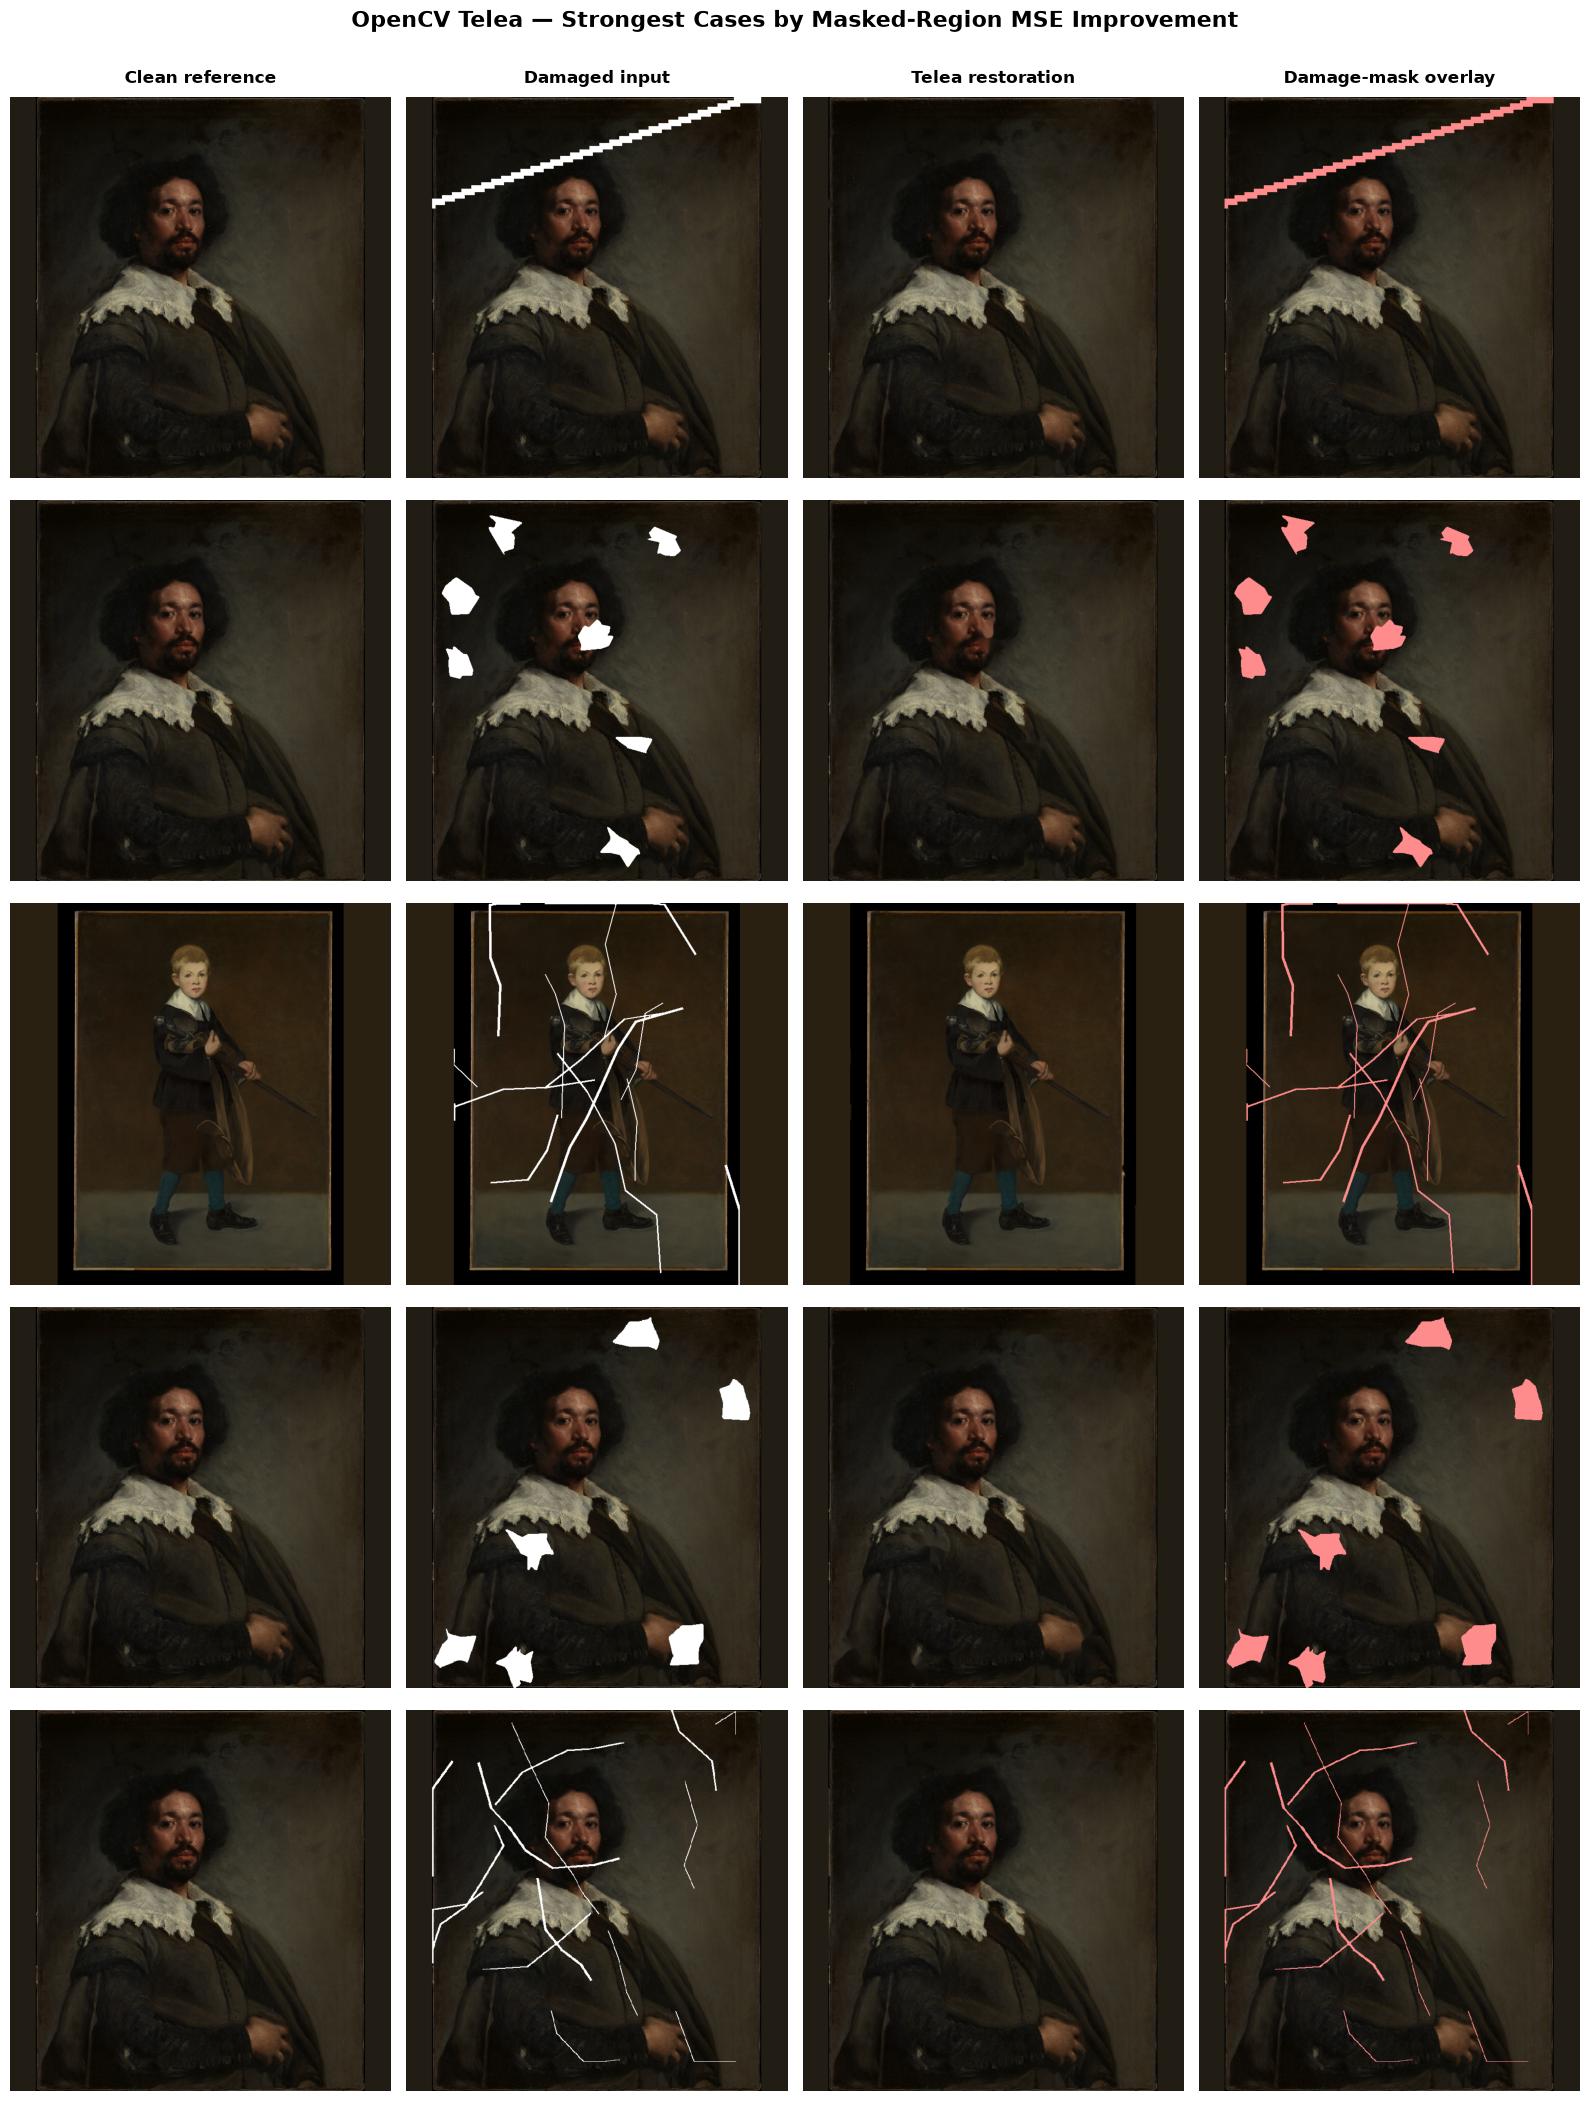

Saved gallery: D:\Masters\FH\Thesis\painting-restoration-eval\reports\figures\opencv_telea_classical_metrics\opencv_telea_best_cases_masked_region.png


In [36]:
best_gallery_path = (
    ranking_figure_dir
    / "opencv_telea_best_cases_masked_region.png"
)

plot_ranked_case_gallery(
    cases_df=best_visual_cases_df,
    gallery_title=(
        "OpenCV Telea — Strongest Cases "
        "by Masked-Region MSE Improvement"
    ),
    output_path=best_gallery_path,
)

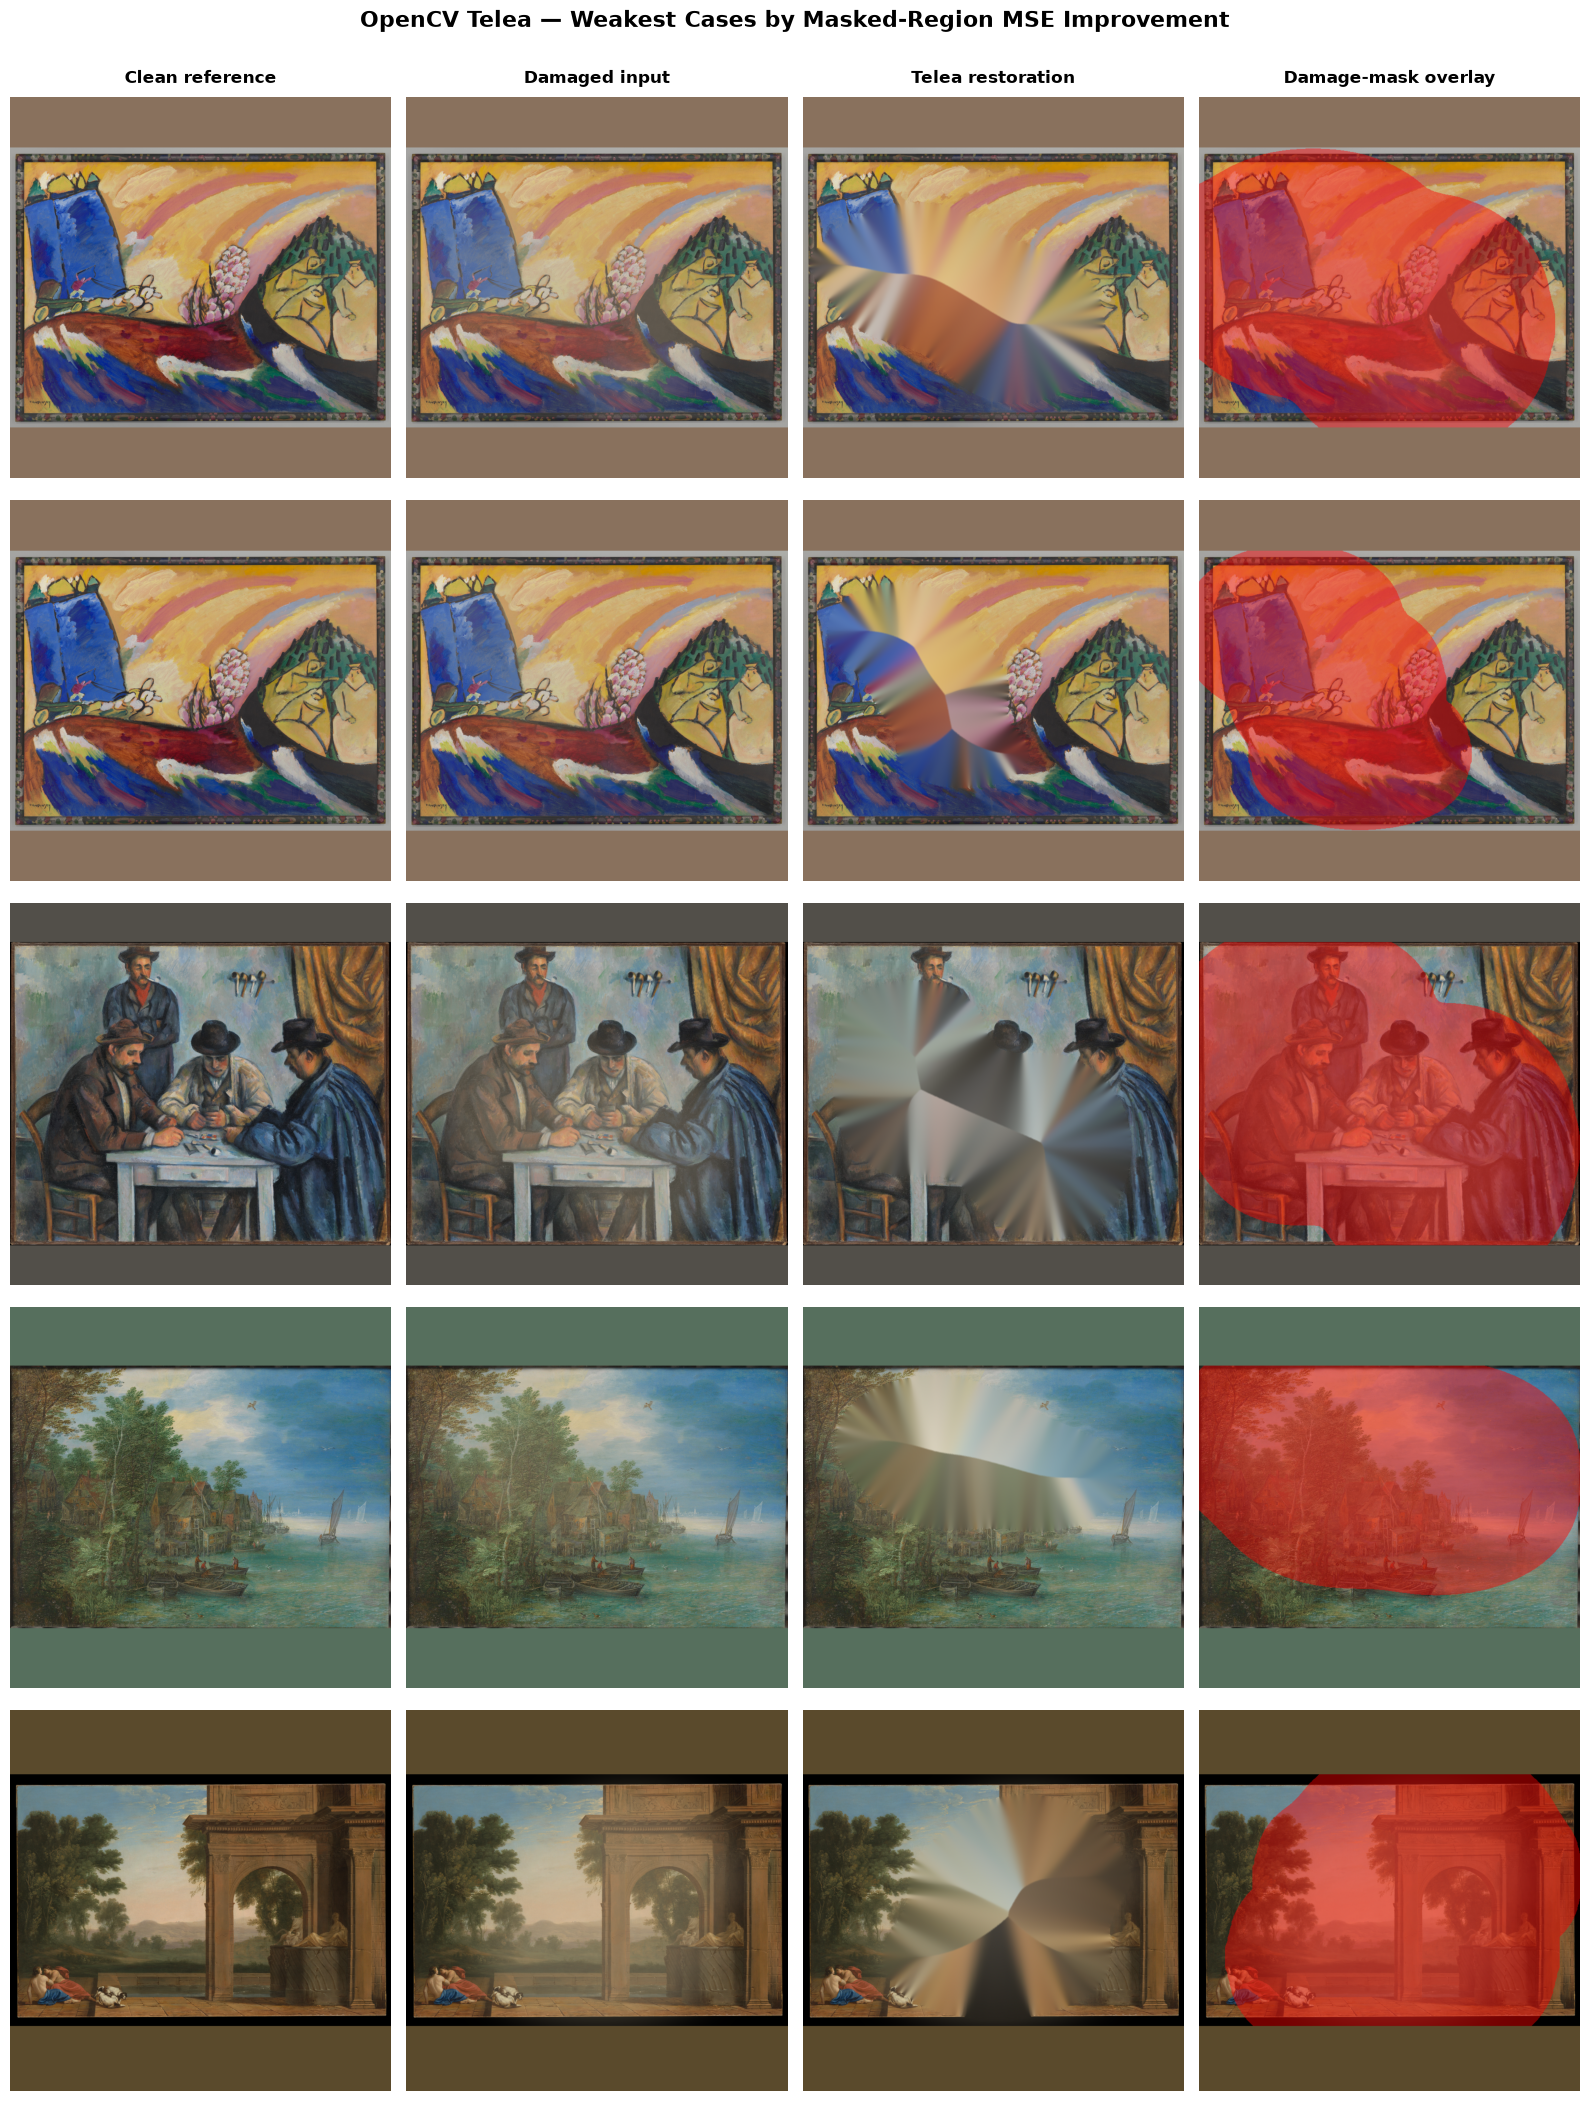

Saved gallery: D:\Masters\FH\Thesis\painting-restoration-eval\reports\figures\opencv_telea_classical_metrics\opencv_telea_worst_cases_masked_region.png


In [37]:
worst_gallery_path = (
    ranking_figure_dir
    / "opencv_telea_worst_cases_masked_region.png"
)

plot_ranked_case_gallery(
    cases_df=worst_visual_cases_df,
    gallery_title=(
        "OpenCV Telea — Weakest Cases "
        "by Masked-Region MSE Improvement"
    ),
    output_path=worst_gallery_path,
)

In [38]:
improvement_metrics = {
    "MSE": "mse_improvement",
    "MAE": "mae_improvement",
    "PSNR": "psnr_improvement",
    "SSIM": "ssim_improvement",
}

improvement_rate_rows = []

for (
    dataset_name,
    evaluation_region,
), group_df in reloaded_all_metrics_df.groupby(
    [
        "dataset_name",
        "evaluation_region",
    ],
    dropna=False,
    sort=True,
):
    for metric_label, metric_column in (
        improvement_metrics.items()
    ):
        if metric_column not in group_df.columns:
            continue

        valid_values = (
            group_df[metric_column]
            .dropna()
        )

        if valid_values.empty:
            continue

        improvement_rate_rows.append(
            {
                "dataset_name": dataset_name,
                "evaluation_region": evaluation_region,
                "metric": metric_label,
                "valid_cases": len(valid_values),
                "improved_cases": int(
                    valid_values.gt(0).sum()
                ),
                "unchanged_cases": int(
                    valid_values.eq(0).sum()
                ),
                "worsened_cases": int(
                    valid_values.lt(0).sum()
                ),
                "improvement_rate": float(
                    valid_values.gt(0).mean()
                ),
                "median_improvement": float(
                    valid_values.median()
                ),
                "mean_improvement": float(
                    valid_values.mean()
                ),
            }
        )

improvement_rate_summary_df = pd.DataFrame(
    improvement_rate_rows
)

improvement_rate_summary_df[
    "improvement_percentage"
] = (
    improvement_rate_summary_df[
        "improvement_rate"
    ]
    * 100
).round(2)

display(
    improvement_rate_summary_df.sort_values(
        [
            "dataset_name",
            "evaluation_region",
            "metric",
        ]
    )
)

improvement_rate_output_path = (
    metrics_dir
    / "summary_classical_opencv_telea_improvement_rates.csv"
)

improvement_rate_summary_df.to_csv(
    improvement_rate_output_path,
    index=False,
)

print(
    "Saved improvement-rate summary to:"
)

print(improvement_rate_output_path)

,dataset_name,evaluation_region,metric,valid_cases,improved_cases,unchanged_cases,worsened_cases,improvement_rate,median_improvement,mean_improvement,improvement_percentage
1,canonical,boundary_region,MAE,200,200,0,0,1.00,66.129349,64.636732,100.0
0,canonical,boundary_region,MSE,200,200,0,0,1.00,12632.810051,12064.245727,100.0
2,canonical,boundary_region,PSNR,200,200,0,0,1.00,21.678032,21.483043,100.0
4,canonical,content_region,MAE,250,200,50,0,0.80,5.531257,7.505223,80.0
3,canonical,content_region,MSE,250,200,50,0,0.80,949.578077,1450.099712,80.0
...,...,...,...,...,...,...,...,...,...,...,...
78,synthetic,masked_region,MSE,50,1,5,44,0.02,-11.240961,-159.089020,2.0
80,synthetic,masked_region,PSNR,50,1,5,44,0.02,-7.158779,-8.236007,2.0
82,synthetic,outside_mask_region,MAE,50,0,50,0,0.00,0.000000,0.000000,0.0
81,synthetic,outside_mask_region,MSE,50,0,50,0,0.00,0.000000,0.000000,0.0


Saved improvement-rate summary to:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\summary_classical_opencv_telea_improvement_rates.csv


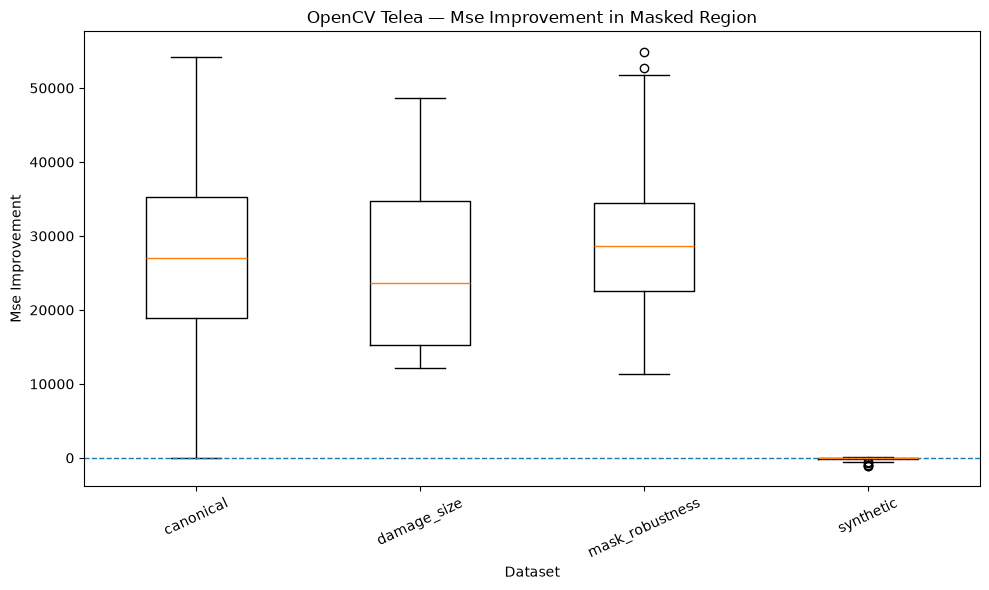

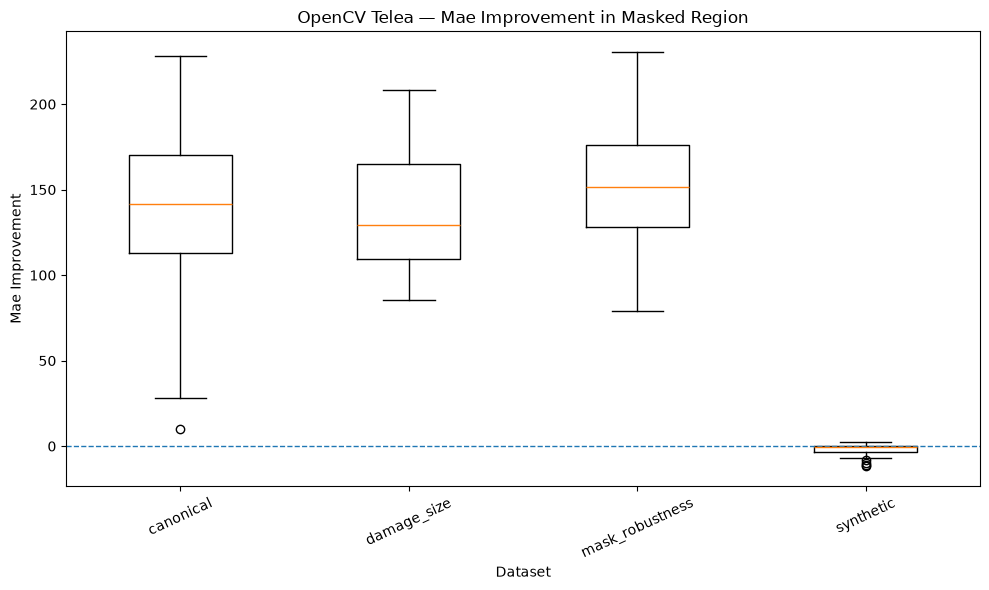

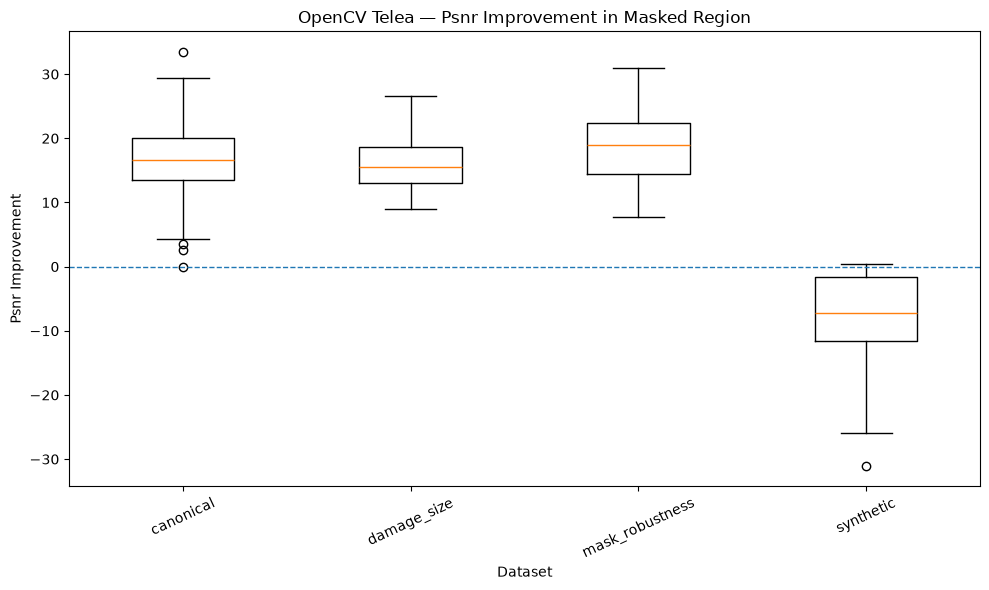

Saved distribution figures:
D:\Masters\FH\Thesis\painting-restoration-eval\reports\figures\opencv_telea_classical_metrics\distribution_mse_improvement_masked_region.png
D:\Masters\FH\Thesis\painting-restoration-eval\reports\figures\opencv_telea_classical_metrics\distribution_mae_improvement_masked_region.png
D:\Masters\FH\Thesis\painting-restoration-eval\reports\figures\opencv_telea_classical_metrics\distribution_psnr_improvement_masked_region.png


In [40]:
distribution_metric_columns = [
    column
    for column in [
        "mse_improvement",
        "mae_improvement",
        "psnr_improvement",
    ]
    if column in ranking_source_df.columns
]

if not distribution_metric_columns:
    raise ValueError(
        "No supported improvement metrics are available "
        "for distribution plotting."
    )

distribution_figure_paths = []

for metric_column in distribution_metric_columns:
    plot_df = (
        ranking_source_df[
            [
                "dataset_name",
                metric_column,
            ]
        ]
        .dropna()
        .copy()
    )

    if plot_df.empty:
        print(
            f"Skipping {metric_column}: "
            "no valid values."
        )
        continue

    dataset_names = (
        plot_df["dataset_name"]
        .dropna()
        .astype(str)
        .sort_values()
        .unique()
        .tolist()
    )

    dataset_values = [
        plot_df.loc[
            plot_df["dataset_name"]
            .astype(str)
            .eq(dataset_name),
            metric_column,
        ].to_numpy()
        for dataset_name in dataset_names
    ]

    figure, axis = plt.subplots(
        figsize=(10, 6)
    )

    axis.boxplot(
        dataset_values,
        tick_labels=dataset_names,
        showfliers=True,
    )

    axis.axhline(
        0,
        linewidth=1,
        linestyle="--",
    )

    axis.set_title(
        f"OpenCV Telea — "
        f"{metric_column.replace('_', ' ').title()} "
        f"in {ranking_region.replace('_', ' ').title()}"
    )

    axis.set_xlabel("Dataset")
    axis.set_ylabel(
        metric_column.replace("_", " ").title()
    )

    axis.tick_params(
        axis="x",
        rotation=25,
    )

    figure.tight_layout()

    output_path = (
        ranking_figure_dir
        / (
            f"distribution_{metric_column}_"
            f"{ranking_region}.png"
        )
    )

    figure.savefig(
        output_path,
        dpi=200,
        bbox_inches="tight",
    )

    plt.show()
    plt.close(figure)

    distribution_figure_paths.append(
        output_path
    )

print("Saved distribution figures:")

for path in distribution_figure_paths:
    print(path)

In [41]:
def classify_restoration_outcome(
    improvement_value,
):
    if pd.isna(improvement_value):
        return "not available"

    if improvement_value > 0:
        return "improved"

    if improvement_value < 0:
        return "worsened"

    return "unchanged"


def build_case_summary_table(
    cases_df,
    ranking_group,
):
    summary_columns = [
        column
        for column in [
            "rank",
            "dataset_name",
            "painting_id",
            "case_id",
            "category",
            "title",
            "mask_type",
            "mask_variant",
            "damage_level",
            "degradation_type",
            "mask_fraction",
            "damaged_mse",
            "restored_mse",
            "mse_improvement",
            "damaged_psnr",
            "restored_psnr",
            "psnr_improvement",
        ]
        if column in cases_df.columns
    ]

    summary_df = (
        cases_df[
            summary_columns
        ]
        .copy()
    )

    summary_df.insert(
        1,
        "ranking_group",
        ranking_group,
    )

    summary_df[
        "restoration_outcome"
    ] = summary_df[
        "mse_improvement"
    ].map(
        classify_restoration_outcome
    )

    summary_df[
        "interpretation"
    ] = summary_df.apply(
        lambda row: (
            f"Telea {row['restoration_outcome']} "
            f"the masked region, with an MSE change "
            f"of {row['mse_improvement']:.6f}"
            + (
                f" and PSNR change of "
                f"{row['psnr_improvement']:.3f} dB."
                if (
                    "psnr_improvement" in row.index
                    and pd.notna(
                        row["psnr_improvement"]
                    )
                )
                else "."
            )
        ),
        axis=1,
    )

    return summary_df


best_case_summary_df = (
    build_case_summary_table(
        best_cases_df,
        ranking_group="best",
    )
)

worst_case_summary_df = (
    build_case_summary_table(
        worst_cases_df,
        ranking_group="worst",
    )
)

ranked_case_summary_df = pd.concat(
    [
        best_case_summary_df,
        worst_case_summary_df,
    ],
    ignore_index=True,
    sort=False,
)

print("Interpretation-ready strongest cases:")

display(best_case_summary_df)

print("\nInterpretation-ready weakest cases:")

display(worst_case_summary_df)

Interpretation-ready strongest cases:


,rank,ranking_group,dataset_name,painting_id,case_id,category,title,mask_type,damaged_mse,restored_mse,mse_improvement,damaged_psnr,restored_psnr,psnr_improvement,restoration_outcome,interpretation
0,1,best,mask_robustness,p001,p001__scratch_thin__variant_01,portrait_figure,Juan de Pareja,NaN,54909.476562,44.402840,54865.073723,0.734331,31.656696,30.922366,improved,"Telea improved the masked region, with an MSE ..."
1,2,best,canonical,p001,p001_loss_small,portrait_figure,Juan de Pareja,NaN,54324.203125,68.437965,54255.765160,0.780870,29.777833,28.996963,improved,"Telea improved the masked region, with an MSE ..."
2,3,best,canonical,p006,p006_scratch_thin,portrait_figure,Boy with a Sword,NaN,53555.175781,61.864239,53493.311543,0.842789,30.216407,29.373618,improved,"Telea improved the masked region, with an MSE ..."
3,4,best,mask_robustness,p001,p001__loss_small__variant_03,portrait_figure,Juan de Pareja,NaN,52737.828125,100.288528,52637.539597,0.909581,28.118291,27.208710,improved,"Telea improved the masked region, with an MSE ..."
4,5,best,mask_robustness,p001,p001__scratch_thin__variant_04,portrait_figure,Juan de Pareja,NaN,51953.406250,148.937805,51804.468445,0.974663,26.400754,25.426091,improved,"Telea improved the masked region, with an MSE ..."
5,6,best,mask_robustness,p001,p001__scratch_thin__variant_02,portrait_figure,Juan de Pareja,NaN,51236.269531,105.263435,51131.006096,1.035029,27.908028,26.873000,improved,"Telea improved the masked region, with an MSE ..."
6,7,best,mask_robustness,p001,p001__loss_small__variant_01,portrait_figure,Juan de Pareja,NaN,50764.437500,246.179489,50518.258011,1.075208,24.218285,23.143077,improved,"Telea improved the masked region, with an MSE ..."
7,8,best,mask_robustness,p001,p001__loss_small__variant_04,portrait_figure,Juan de Pareja,NaN,50626.421875,158.545547,50467.876328,1.087031,26.129263,25.042232,improved,"Telea improved the masked region, with an MSE ..."
8,9,best,mask_robustness,p001,p001__loss_small__variant_05,portrait_figure,Juan de Pareja,NaN,50742.828125,286.486603,50456.341522,1.077057,23.559760,22.482704,improved,"Telea improved the masked region, with an MSE ..."
9,10,best,canonical,p001,p001_mixed_damage,portrait_figure,Juan de Pareja,NaN,50902.804688,591.841553,50310.963135,1.063386,20.408749,19.345363,improved,"Telea improved the masked region, with an MSE ..."



Interpretation-ready weakest cases:


,rank,ranking_group,dataset_name,painting_id,case_id,category,title,mask_type,damaged_mse,restored_mse,mse_improvement,damaged_psnr,restored_psnr,psnr_improvement,restoration_outcome,interpretation
0,1,worst,synthetic,p039,p039__partial_transparency__severe,abstraction_surrealism,Painting with Troika,NaN,344.268341,1404.778687,-1060.510345,22.761833,16.654725,-6.107108,worsened,"Telea worsened the masked region, with an MSE ..."
1,2,worst,synthetic,p039,p039__partial_transparency__moderate,abstraction_surrealism,Painting with Troika,NaN,121.302780,1155.099609,-1033.796829,27.292096,17.504609,-9.787487,worsened,"Telea worsened the masked region, with an MSE ..."
2,3,worst,synthetic,p043,p043__partial_transparency__severe,high_texture_brushwork,The Card Players,NaN,547.333557,1488.960815,-941.627258,20.748283,16.401971,-4.346312,worsened,"Telea worsened the masked region, with an MSE ..."
3,4,worst,synthetic,p026,p026__partial_transparency__severe,architecture_structured,View of a Village along a River,NaN,224.509598,860.257690,-635.748093,24.618454,18.784518,-5.833937,worsened,"Telea worsened the masked region, with an MSE ..."
4,5,worst,synthetic,p018,p018__partial_transparency__severe,landscape_natural,Classical Landscape with Figures,NaN,556.760742,1140.882202,-584.121460,20.674118,17.558396,-3.115722,worsened,"Telea worsened the masked region, with an MSE ..."
5,6,worst,synthetic,p018,p018__water_stain__mild,landscape_natural,Classical Landscape with Figures,NaN,16.520813,521.230103,-504.709290,35.950489,20.960509,-14.989981,worsened,"Telea worsened the masked region, with an MSE ..."
6,7,worst,synthetic,p043,p043__partial_transparency__moderate,high_texture_brushwork,The Card Players,NaN,108.313934,599.729431,-491.415497,27.783960,20.351250,-7.432710,worsened,"Telea worsened the masked region, with an MSE ..."
7,8,worst,synthetic,p039,p039__water_stain__moderate,abstraction_surrealism,Painting with Troika,NaN,73.926476,538.909485,-464.983009,29.442804,20.815645,-8.627158,worsened,"Telea worsened the masked region, with an MSE ..."
8,9,worst,synthetic,p039,p039__partial_transparency__mild,abstraction_surrealism,Painting with Troika,NaN,7.876428,291.830383,-283.953956,39.167511,23.479499,-15.688012,worsened,"Telea worsened the masked region, with an MSE ..."
9,10,worst,synthetic,p043,p043__partial_transparency__mild,high_texture_brushwork,The Card Players,NaN,30.142212,309.440308,-279.298096,33.339052,23.225035,-10.114018,worsened,"Telea worsened the masked region, with an MSE ..."


In [42]:
interpretation_output_paths = {
    "best_case_summary": (
        metrics_dir
        / "summary_best_cases_opencv_telea.csv"
    ),
    "worst_case_summary": (
        metrics_dir
        / "summary_worst_cases_opencv_telea.csv"
    ),
    "combined_case_summary": (
        metrics_dir
        / "summary_ranked_cases_opencv_telea.csv"
    ),
}

best_case_summary_df.to_csv(
    interpretation_output_paths[
        "best_case_summary"
    ],
    index=False,
)

worst_case_summary_df.to_csv(
    interpretation_output_paths[
        "worst_case_summary"
    ],
    index=False,
)

ranked_case_summary_df.to_csv(
    interpretation_output_paths[
        "combined_case_summary"
    ],
    index=False,
)

masked_mse_summary_df = (
    improvement_rate_summary_df.loc[
        improvement_rate_summary_df[
            "evaluation_region"
        ].eq(ranking_region)
        &
        improvement_rate_summary_df[
            "metric"
        ].eq("MSE")
    ]
    .copy()
    .sort_values("dataset_name")
)

finding_lines = [
    "# OpenCV Telea Classical Metric Findings",
    "",
    (
        f"Primary ranking region: "
        f"`{ranking_region}`."
    ),
    (
        f"Primary ranking metric: "
        f"`{ranking_metric}`."
    ),
    "",
    "## Improvement rates by dataset",
    "",
]

for _, row in masked_mse_summary_df.iterrows():
    finding_lines.append(
        (
            f"- {row['dataset_name']}: "
            f"{row['improvement_percentage']:.2f}% "
            f"of valid cases improved in masked-region MSE "
            f"({int(row['improved_cases'])}/"
            f"{int(row['valid_cases'])})."
        )
    )

finding_lines.extend(
    [
        "",
        "## Strongest cases",
        "",
    ]
)

for _, row in best_case_summary_df.iterrows():
    finding_lines.append(
        (
            f"- Rank {int(row['rank'])}: "
            f"{row['dataset_name']} / "
            f"{row['case_id']} — "
            f"{row['interpretation']}"
        )
    )

finding_lines.extend(
    [
        "",
        "## Weakest cases",
        "",
    ]
)

for _, row in worst_case_summary_df.iterrows():
    finding_lines.append(
        (
            f"- Rank {int(row['rank'])}: "
            f"{row['dataset_name']} / "
            f"{row['case_id']} — "
            f"{row['interpretation']}"
        )
    )

findings_output_path = (
    metrics_dir
    / "findings_opencv_telea_classical_metrics.md"
)

findings_output_path.write_text(
    "\n".join(finding_lines),
    encoding="utf-8",
)

saved_interpretation_outputs_df = pd.DataFrame(
    [
        {
            "output_name": name,
            "output_path": str(path),
            "exists": path.exists(),
        }
        for name, path
        in {
            **interpretation_output_paths,
            "findings_markdown": (
                findings_output_path
            ),
        }.items()
    ]
)

display(saved_interpretation_outputs_df)

if not saved_interpretation_outputs_df[
    "exists"
].all():
    raise FileNotFoundError(
        "One or more interpretation outputs "
        "were not saved."
    )

print(
    "Interpretation tables and findings "
    "saved successfully."
)

,output_name,output_path,exists
0,best_case_summary,D:\Masters\FH\Thesis\painting-restoration-eval...,True
1,worst_case_summary,D:\Masters\FH\Thesis\painting-restoration-eval...,True
2,combined_case_summary,D:\Masters\FH\Thesis\painting-restoration-eval...,True
3,findings_markdown,D:\Masters\FH\Thesis\painting-restoration-eval...,True


Interpretation tables and findings saved successfully.


In [43]:
final_output_records = []

for output_name, output_path in {
    **metric_output_paths,
    **summary_output_paths,
    **ranking_output_paths,
    **interpretation_output_paths,
    "improvement_rates": (
        improvement_rate_output_path
    ),
    "findings_markdown": (
        findings_output_path
    ),
    "best_gallery": (
        best_gallery_path
    ),
    "worst_gallery": (
        worst_gallery_path
    ),
}.items():
    output_path = Path(output_path)

    final_output_records.append(
        {
            "output_name": output_name,
            "output_path": str(output_path),
            "exists": output_path.exists(),
            "file_size_bytes": (
                output_path.stat().st_size
                if output_path.exists()
                else 0
            ),
            "suffix": output_path.suffix.lower(),
        }
    )

for figure_path in distribution_figure_paths:
    figure_path = Path(figure_path)

    final_output_records.append(
        {
            "output_name": figure_path.stem,
            "output_path": str(figure_path),
            "exists": figure_path.exists(),
            "file_size_bytes": (
                figure_path.stat().st_size
                if figure_path.exists()
                else 0
            ),
            "suffix": figure_path.suffix.lower(),
        }
    )

final_output_inventory_df = (
    pd.DataFrame(final_output_records)
    .sort_values(
        [
            "suffix",
            "output_name",
        ]
    )
    .reset_index(drop=True)
)

display(final_output_inventory_df)

missing_final_outputs_df = (
    final_output_inventory_df.loc[
        ~final_output_inventory_df[
            "exists"
        ]
    ]
)

empty_final_outputs_df = (
    final_output_inventory_df.loc[
        final_output_inventory_df[
            "exists"
        ]
        &
        final_output_inventory_df[
            "file_size_bytes"
        ].eq(0)
    ]
)

if not missing_final_outputs_df.empty:
    display(missing_final_outputs_df)

    raise FileNotFoundError(
        "One or more expected notebook outputs "
        "are missing."
    )

if not empty_final_outputs_df.empty:
    display(empty_final_outputs_df)

    raise ValueError(
        "One or more notebook outputs are empty."
    )

print(
    f"Verified {len(final_output_inventory_df)} "
    "non-empty output files."
)

,output_name,output_path,exists,file_size_bytes,suffix
0,all,D:\Masters\FH\Thesis\painting-restoration-eval...,True,932135,.csv
1,best_case_summary,D:\Masters\FH\Thesis\painting-restoration-eval...,True,3209,.csv
2,best_overall,D:\Masters\FH\Thesis\painting-restoration-eval...,True,4441,.csv
3,by_dataset,D:\Masters\FH\Thesis\painting-restoration-eval...,True,33054,.csv
4,canonical,D:\Masters\FH\Thesis\painting-restoration-eval...,True,526982,.csv
5,category_region,D:\Masters\FH\Thesis\painting-restoration-eval...,True,17396,.csv
6,combined_case_summary,D:\Masters\FH\Thesis\painting-restoration-eval...,True,6450,.csv
7,damage_size,D:\Masters\FH\Thesis\painting-restoration-eval...,True,89052,.csv
8,dataset_mask_region,D:\Masters\FH\Thesis\painting-restoration-eval...,True,3282,.csv
9,dataset_region,D:\Masters\FH\Thesis\painting-restoration-eval...,True,3248,.csv


Verified 21 non-empty output files.


In [44]:
final_validation_checks = []


def add_final_check(
    check_name,
    passed,
    detail,
):
    final_validation_checks.append(
        {
            "check": check_name,
            "passed": bool(passed),
            "detail": detail,
        }
    )


add_final_check(
    check_name="input_manifest_not_empty",
    passed=not metrics_input_df.empty,
    detail=(
        f"{len(metrics_input_df):,} "
        "restoration cases loaded."
    ),
)

add_final_check(
    check_name="metric_row_count",
    passed=(
        len(full_metrics_df)
        == expected_rows
    ),
    detail=(
        f"Expected {expected_rows:,}; "
        f"computed {len(full_metrics_df):,}."
    ),
)

add_final_check(
    check_name="metric_key_uniqueness",
    passed=not full_metrics_df.duplicated(
        subset=[
            "dataset_name",
            "case_id",
            "model_name",
            "evaluation_region",
        ],
        keep=False,
    ).any(),
    detail=(
        "Metric keys must be unique across "
        "dataset, case, model, and region."
    ),
)

add_final_check(
    check_name="no_metric_errors",
    passed=(
        "status" not in full_metrics_df.columns
        or not full_metrics_df[
            "status"
        ].astype(str).str.lower().eq(
            "error"
        ).any()
    ),
    detail=(
        "No metric rows should have "
        "status='error'."
    ),
)

add_final_check(
    check_name="all_input_paths_exist",
    passed=all(
        metrics_input_df[
            column
        ].map(
            lambda value: Path(
                str(value)
            ).exists()
        ).all()
        for column in [
            "clean_path",
            "damaged_path",
            "restored_path",
            "mask_path",
        ]
    ),
    detail=(
        "All clean, damaged, restored, "
        "and mask paths must exist."
    ),
)

add_final_check(
    check_name="best_case_ranking_available",
    passed=not best_cases_df.empty,
    detail=(
        f"{len(best_cases_df)} best cases ranked."
    ),
)

add_final_check(
    check_name="worst_case_ranking_available",
    passed=not worst_cases_df.empty,
    detail=(
        f"{len(worst_cases_df)} worst cases ranked."
    ),
)

add_final_check(
    check_name="summary_tables_available",
    passed=(
        not summary_by_dataset_region_df.empty
        and not improvement_rate_summary_df.empty
    ),
    detail=(
        "Dataset-region and improvement-rate "
        "summaries must be populated."
    ),
)

add_final_check(
    check_name="all_outputs_exist",
    passed=final_output_inventory_df[
        "exists"
    ].all(),
    detail=(
        f"{len(final_output_inventory_df)} "
        "output files checked."
    ),
)

final_notebook_validation_df = (
    pd.DataFrame(final_validation_checks)
)

display(final_notebook_validation_df)

failed_final_checks_df = (
    final_notebook_validation_df.loc[
        ~final_notebook_validation_df[
            "passed"
        ]
    ]
)

if not failed_final_checks_df.empty:
    display(failed_final_checks_df)

    raise ValueError(
        "Final notebook validation failed."
    )

print(
    "End-to-end notebook validation passed."
)

,check,passed,detail
0,input_manifest_not_empty,True,410 restoration cases loaded.
1,metric_row_count,True,"Expected 2,260; computed 2,260."
2,metric_key_uniqueness,True,"Metric keys must be unique across dataset, cas..."
3,no_metric_errors,True,No metric rows should have status='error'.
4,all_input_paths_exist,True,"All clean, damaged, restored, and mask paths m..."
5,best_case_ranking_available,True,10 best cases ranked.
6,worst_case_ranking_available,True,10 worst cases ranked.
7,summary_tables_available,True,Dataset-region and improvement-rate summaries ...
8,all_outputs_exist,True,21 output files checked.


End-to-end notebook validation passed.


In [46]:
import json

reproducibility_manifest = {
    "notebook": (
        "09 OpenCV Classical Metrics"
    ),
    "metric_module": METRIC_MODULE_NAME,
    "metric_version": METRIC_VERSION,
    "target_size": target_size,
    "mask_bbox_margin": mask_bbox_margin,
    "boundary_width": boundary_width,
    "ranking_region": ranking_region,
    "ranking_metric": ranking_metric,
    "input_case_count": int(
        len(metrics_input_df)
    ),
    "metric_row_count": int(
        len(full_metrics_df)
    ),
    "expected_metric_row_count": int(
        expected_rows
    ),
    "datasets": sorted(
        metrics_input_df[
            "dataset_name"
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    ),
    "evaluation_regions": sorted(
        full_metrics_df[
            "evaluation_region"
        ]
        .dropna()
        .astype(str)
        .unique()
        .tolist()
    ),
    "metric_columns": [
        column
        for column in metric_columns
        if column in full_metrics_df.columns
    ],
    "output_files": (
        final_output_inventory_df[
            "output_path"
        ].tolist()
    ),
}

reproducibility_manifest_path = (
    metrics_dir
    / "manifest_opencv_telea_classical_metrics.json"
)

reproducibility_manifest_path.write_text(
    json.dumps(
        reproducibility_manifest,
        indent=2,
    ),
    encoding="utf-8",
)

if not reproducibility_manifest_path.exists():
    raise FileNotFoundError(
        "Reproducibility manifest was not saved."
    )

print(
    "Saved reproducibility manifest:"
)

print(reproducibility_manifest_path)

Saved reproducibility manifest:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\manifest_opencv_telea_classical_metrics.json


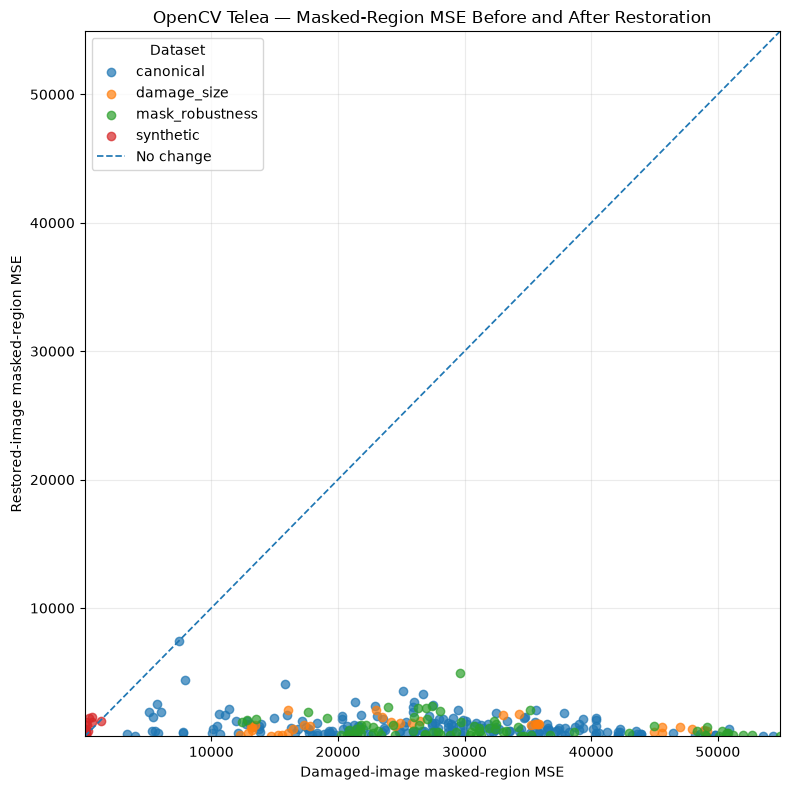

Cases below identity line: 311
Cases on identity line: 5
Cases above identity line: 44
Saved figure: D:\Masters\FH\Thesis\painting-restoration-eval\reports\figures\opencv_telea_classical_metrics\diagnostic_masked_region_mse_before_after.png


In [48]:
mse_diagnostic_columns = [
    "dataset_name",
    "case_id",
    "damaged_mse",
    "restored_mse",
]

missing_mse_diagnostic_columns = [
    column
    for column in mse_diagnostic_columns
    if column not in ranking_source_df.columns
]

if missing_mse_diagnostic_columns:
    raise ValueError(
        "Masked-region MSE diagnostic plot is missing "
        f"required columns: {missing_mse_diagnostic_columns}"
    )

mse_diagnostic_df = (
    ranking_source_df[
        mse_diagnostic_columns
    ]
    .dropna(
        subset=[
            "damaged_mse",
            "restored_mse",
        ]
    )
    .copy()
)

if mse_diagnostic_df.empty:
    raise ValueError(
        "No valid masked-region MSE values are "
        "available for diagnostic plotting."
    )

mse_axis_minimum = min(
    mse_diagnostic_df["damaged_mse"].min(),
    mse_diagnostic_df["restored_mse"].min(),
)

mse_axis_maximum = max(
    mse_diagnostic_df["damaged_mse"].max(),
    mse_diagnostic_df["restored_mse"].max(),
)

figure, axis = plt.subplots(
    figsize=(8, 8)
)

for dataset_name, dataset_df in (
    mse_diagnostic_df.groupby(
        "dataset_name",
        sort=True,
        dropna=False,
    )
):
    axis.scatter(
        dataset_df["damaged_mse"],
        dataset_df["restored_mse"],
        label=str(dataset_name),
        alpha=0.7,
        s=36,
    )

axis.plot(
    [
        mse_axis_minimum,
        mse_axis_maximum,
    ],
    [
        mse_axis_minimum,
        mse_axis_maximum,
    ],
    linestyle="--",
    linewidth=1.25,
    label="No change",
)

axis.set_xlim(
    mse_axis_minimum,
    mse_axis_maximum,
)

axis.set_ylim(
    mse_axis_minimum,
    mse_axis_maximum,
)

axis.set_xlabel(
    "Damaged-image masked-region MSE"
)

axis.set_ylabel(
    "Restored-image masked-region MSE"
)

axis.set_title(
    "OpenCV Telea — Masked-Region MSE "
    "Before and After Restoration"
)

axis.legend(
    title="Dataset",
    loc="best",
)

axis.grid(
    alpha=0.25
)

figure.tight_layout()

mse_before_after_figure_path = (
    ranking_figure_dir
    / "diagnostic_masked_region_mse_before_after.png"
)

figure.savefig(
    mse_before_after_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)

if not mse_before_after_figure_path.exists():
    raise FileNotFoundError(
        "Masked-region MSE diagnostic figure "
        "was not saved."
    )

improved_mse_cases = int(
    (
        mse_diagnostic_df["restored_mse"]
        <
        mse_diagnostic_df["damaged_mse"]
    ).sum()
)

unchanged_mse_cases = int(
    (
        mse_diagnostic_df["restored_mse"]
        ==
        mse_diagnostic_df["damaged_mse"]
    ).sum()
)

worsened_mse_cases = int(
    (
        mse_diagnostic_df["restored_mse"]
        >
        mse_diagnostic_df["damaged_mse"]
    ).sum()
)

print(
    f"Cases below identity line: "
    f"{improved_mse_cases:,}"
)

print(
    f"Cases on identity line: "
    f"{unchanged_mse_cases:,}"
)

print(
    f"Cases above identity line: "
    f"{worsened_mse_cases:,}"
)

print(
    f"Saved figure: "
    f"{mse_before_after_figure_path}"
)

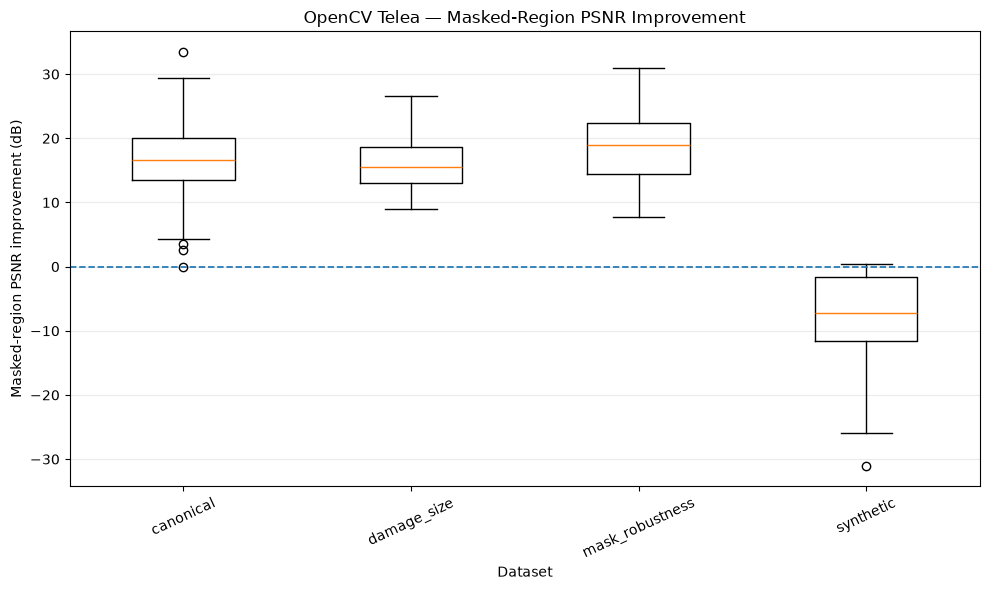

Positive PSNR improvement: 311
Zero PSNR improvement: 5
Negative PSNR improvement: 44
Median PSNR improvement: 15.5799 dB
Saved figure: D:\Masters\FH\Thesis\painting-restoration-eval\reports\figures\opencv_telea_classical_metrics\diagnostic_masked_region_psnr_improvement.png


In [50]:
required_psnr_columns = [
    "dataset_name",
    "case_id",
    "psnr_improvement",
]

missing_psnr_columns = [
    column
    for column in required_psnr_columns
    if column not in ranking_source_df.columns
]

if missing_psnr_columns:
    raise ValueError(
        "Masked-region PSNR diagnostic plot is missing "
        f"required columns: {missing_psnr_columns}"
    )

psnr_diagnostic_df = (
    ranking_source_df[
        required_psnr_columns
    ]
    .dropna(
        subset=[
            "psnr_improvement",
        ]
    )
    .copy()
)

if psnr_diagnostic_df.empty:
    raise ValueError(
        "No valid masked-region PSNR improvement "
        "values are available."
    )

dataset_names = (
    psnr_diagnostic_df["dataset_name"]
    .dropna()
    .astype(str)
    .sort_values()
    .unique()
    .tolist()
)

dataset_psnr_values = [
    psnr_diagnostic_df.loc[
        psnr_diagnostic_df[
            "dataset_name"
        ].astype(str).eq(dataset_name),
        "psnr_improvement",
    ].to_numpy()
    for dataset_name in dataset_names
]

figure, axis = plt.subplots(
    figsize=(10, 6)
)

axis.boxplot(
    dataset_psnr_values,
    tick_labels=dataset_names,
    showfliers=True,
)

axis.axhline(
    0,
    linestyle="--",
    linewidth=1.25,
)

axis.set_xlabel(
    "Dataset"
)

axis.set_ylabel(
    "Masked-region PSNR improvement (dB)"
)

axis.set_title(
    "OpenCV Telea — Masked-Region "
    "PSNR Improvement"
)

axis.tick_params(
    axis="x",
    rotation=25,
)

axis.grid(
    axis="y",
    alpha=0.25,
)

figure.tight_layout()

psnr_improvement_figure_path = (
    ranking_figure_dir
    / "diagnostic_masked_region_psnr_improvement.png"
)

figure.savefig(
    psnr_improvement_figure_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()
plt.close(figure)

if not psnr_improvement_figure_path.exists():
    raise FileNotFoundError(
        "Masked-region PSNR improvement figure "
        "was not saved."
    )

positive_psnr_cases = int(
    psnr_diagnostic_df[
        "psnr_improvement"
    ].gt(0).sum()
)

zero_psnr_cases = int(
    psnr_diagnostic_df[
        "psnr_improvement"
    ].eq(0).sum()
)

negative_psnr_cases = int(
    psnr_diagnostic_df[
        "psnr_improvement"
    ].lt(0).sum()
)

print(
    f"Positive PSNR improvement: "
    f"{positive_psnr_cases:,}"
)

print(
    f"Zero PSNR improvement: "
    f"{zero_psnr_cases:,}"
)

print(
    f"Negative PSNR improvement: "
    f"{negative_psnr_cases:,}"
)

print(
    f"Median PSNR improvement: "
    f"{psnr_diagnostic_df['psnr_improvement'].median():.4f} dB"
)

print(
    f"Saved figure: "
    f"{psnr_improvement_figure_path}"
)

In [51]:
dataset_case_summary_df = (
    metrics_input_df
    .groupby(
        "dataset_name",
        dropna=False,
    )
    .size()
    .rename("input_cases")
    .reset_index()
)

dataset_metric_summary_df = (
    full_metrics_df
    .groupby(
        "dataset_name",
        dropna=False,
    )
    .size()
    .rename("metric_rows")
    .reset_index()
)

final_dataset_summary_df = (
    dataset_case_summary_df.merge(
        dataset_metric_summary_df,
        on="dataset_name",
        how="outer",
        validate="one_to_one",
    )
    .sort_values("dataset_name")
    .reset_index(drop=True)
)

display(final_dataset_summary_df)

print(
    "\nNotebook 09 completed successfully."
)

print(
    f"Input restoration cases: "
    f"{len(metrics_input_df):,}"
)

print(
    f"Classical metric rows: "
    f"{len(full_metrics_df):,}"
)

print(
    f"Evaluation regions: "
    f"{', '.join(sorted(full_metrics_df['evaluation_region'].unique()))}"
)

print(
    f"Best cases ranked: "
    f"{len(best_cases_df)}"
)

print(
    f"Worst cases ranked: "
    f"{len(worst_cases_df)}"
)

print(
    f"Verified output files: "
    f"{len(final_output_inventory_df) + 1}"
)

print(
    "\nPrimary interpretation policy:"
)

print(
    "- Rank restoration performance using "
    "masked-region MSE improvement."
)

print(
    "- Use full-image and content-region metrics "
    "only as broader contextual evidence."
)

print(
    "- Treat sparse-region SSIM values as "
    "intentionally unavailable."
)

print(
    "- Inspect best and worst visual galleries "
    "before drawing qualitative conclusions."
)

,dataset_name,input_cases,metric_rows
0,canonical,250,1300
1,damage_size,35,210
2,mask_robustness,75,450
3,synthetic,50,300



Notebook 09 completed successfully.
Input restoration cases: 410
Classical metric rows: 2,260
Evaluation regions: boundary_region, content_region, full_image, mask_bbox_crop, masked_region, outside_mask_region
Best cases ranked: 10
Worst cases ranked: 10
Verified output files: 22

Primary interpretation policy:
- Rank restoration performance using masked-region MSE improvement.
- Use full-image and content-region metrics only as broader contextual evidence.
- Treat sparse-region SSIM values as intentionally unavailable.
- Inspect best and worst visual galleries before drawing qualitative conclusions.


In [52]:
diagnostic_figure_paths = [
    mse_before_after_figure_path,
    psnr_improvement_figure_path,
]

diagnostic_figure_inventory_df = pd.DataFrame(
    [
        {
            "figure_name": path.stem,
            "figure_path": str(path),
            "exists": path.exists(),
            "file_size_bytes": (
                path.stat().st_size
                if path.exists()
                else 0
            ),
        }
        for path in diagnostic_figure_paths
    ]
)

display(
    diagnostic_figure_inventory_df
)

if not diagnostic_figure_inventory_df[
    "exists"
].all():
    raise FileNotFoundError(
        "One or more diagnostic figures "
        "were not saved."
    )

if diagnostic_figure_inventory_df[
    "file_size_bytes"
].eq(0).any():
    raise ValueError(
        "One or more diagnostic figures "
        "are empty."
    )

print(
    "Original diagnostic plots have been "
    "preserved in the refactored pipeline."
)

,figure_name,figure_path,exists,file_size_bytes
0,diagnostic_masked_region_mse_before_after,D:\Masters\FH\Thesis\painting-restoration-eval...,True,193526
1,diagnostic_masked_region_psnr_improvement,D:\Masters\FH\Thesis\painting-restoration-eval...,True,91563


Original diagnostic plots have been preserved in the refactored pipeline.


# Notebook 09 Summary: OpenCV Telea Classical Metrics

This notebook evaluates OpenCV Telea restorations using classical image-quality metrics across the available restoration datasets.

## Scope

The notebook processes restoration cases from:

- canonical damage cases;
- damage-size sensitivity cases;
- mask-robustness cases;
- synthetic degradation cases.

All manifest paths are resolved against the project root immediately after metadata loading and validated before metric computation.

## Evaluation regions

Metrics are computed for the following regions:

- `full_image`;
- `content_region`;
- `masked_region`;
- `mask_bbox_crop`;
- `boundary_region`;
- `outside_mask_region`.

Sparse or non-rectangular regions are not assigned SSIM values because SSIM requires a contiguous rectangular image region.

## Metrics

For each valid evaluation region, the notebook computes:

- mean squared error;
- mean absolute error;
- peak signal-to-noise ratio;
- structural similarity where applicable.

Metrics are calculated separately for:

- the damaged image against the clean reference;
- the restored image against the clean reference;
- the corresponding restoration improvement.

## Validation

The notebook validates:

- input metadata structure;
- existence of all referenced files;
- expected metric row counts;
- expected evaluation-region counts;
- uniqueness of dataset, case, model, and region keys;
- absence of metric computation errors;
- successful round-trip CSV loading;
- existence and non-zero size of generated outputs.

Expected row counts and region counts are derived dynamically from the metadata and masks rather than being hardcoded.

## Ranking policy

Best and worst restoration cases are ranked using:

- evaluation region: `masked_region`;
- primary metric: `mse_improvement`.

Masked-region evaluation is used because it measures restoration performance directly inside the damaged area and avoids dilution from unchanged image regions.

The ranking outputs include:

- strongest cases overall;
- weakest cases overall;
- strongest and weakest cases within each dataset;
- interpretation-ready ranking tables.

## Diagnostic plots

The notebook produces:

- masked-region MSE before versus after restoration;
- masked-region PSNR improvement;
- metric-improvement distributions by dataset;
- strongest-case visual gallery;
- weakest-case visual gallery.

The MSE before-versus-after plot uses the identity line as the no-change reference:

- points below the line indicate improvement;
- points above the line indicate worsening.

## Outputs

The notebook saves:

- unified classical metric results;
- dataset-specific metric results;
- dataset and region summaries;
- improvement-rate summaries;
- ranked best and worst cases;
- interpretation-ready case summaries;
- diagnostic figures;
- best and worst case galleries;
- a findings report;
- a reproducibility manifest.

## Interpretation policy

The notebook uses masked-region metrics as the primary evidence for restoration effectiveness.

Full-image and content-region results are retained as contextual measures but are not treated as the main restoration-quality indicators.

Classical metrics quantify pixel-level reconstruction quality. They do not independently establish historical plausibility, semantic correctness, stylistic consistency, or conservation suitability. Those questions are addressed by later perceptual, semantic, texture, uncertainty, and reporting stages of the evaluation framework.